/tmp/ipykernel_1937372/3203075192.py:49: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)


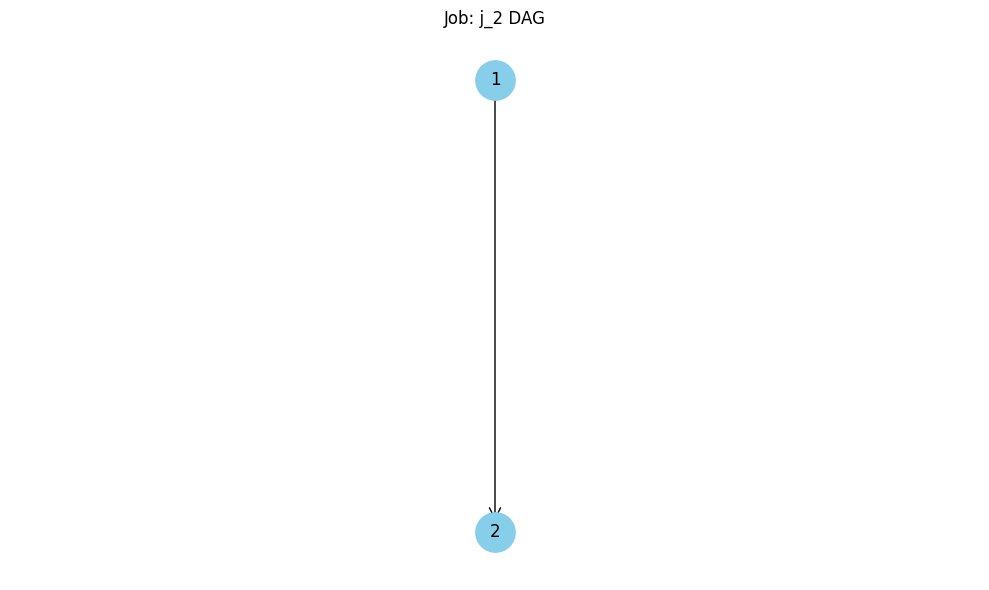

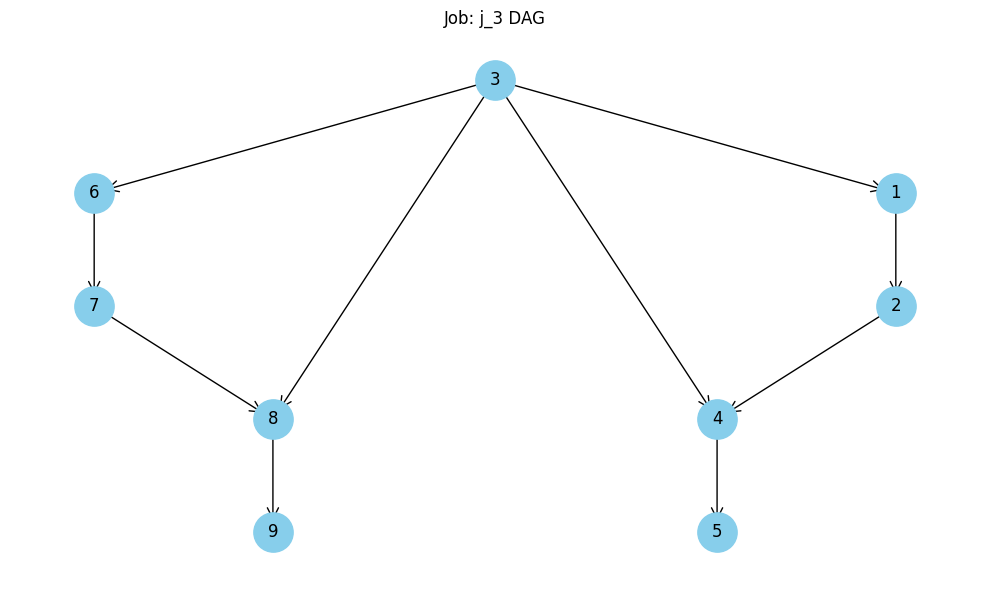

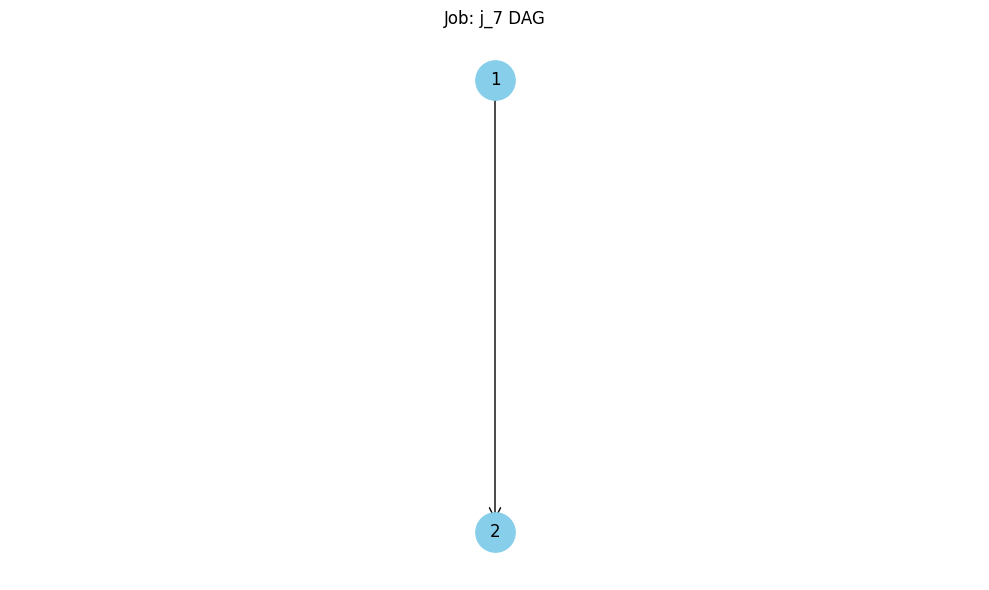

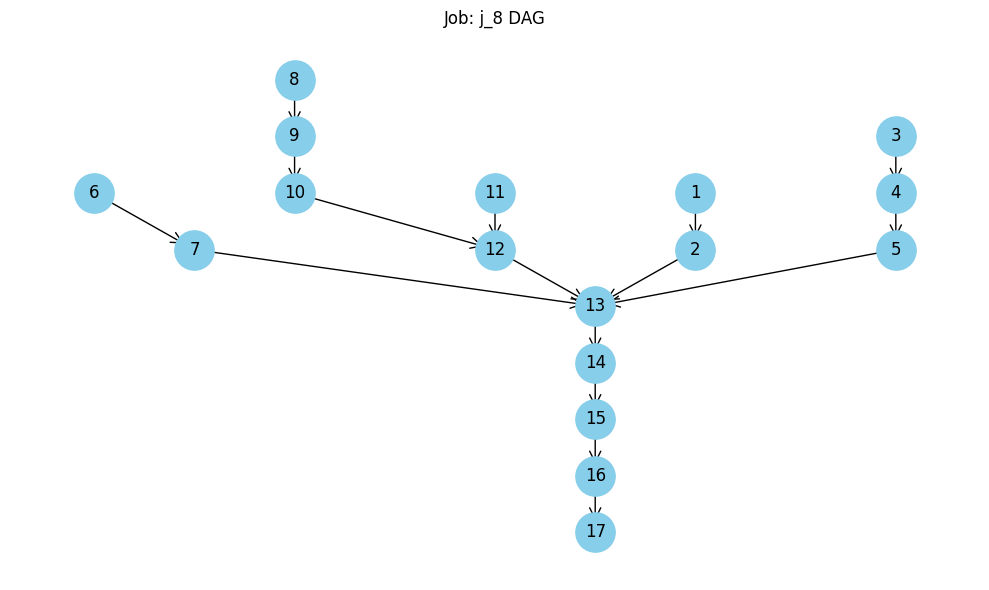

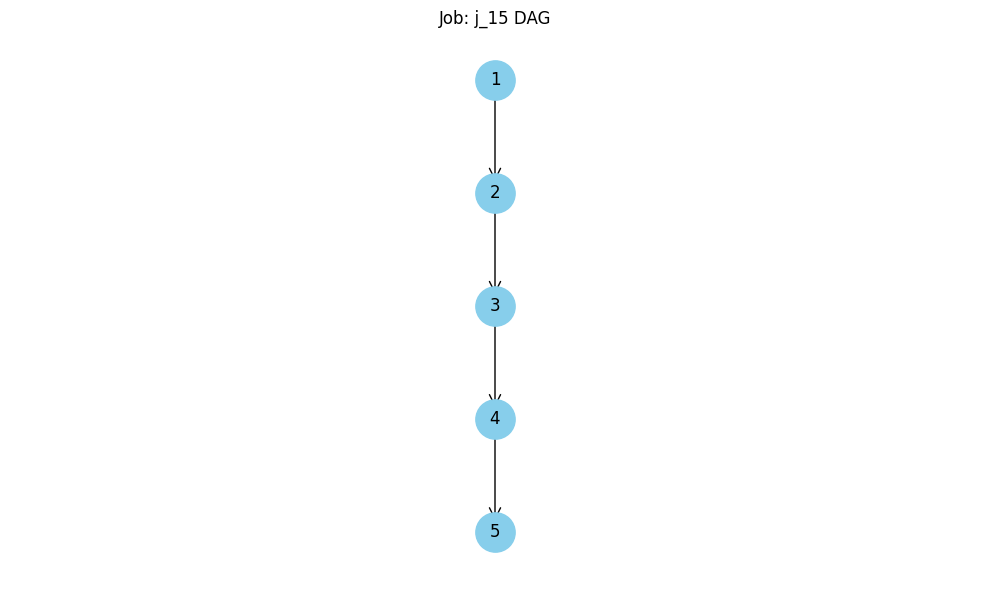

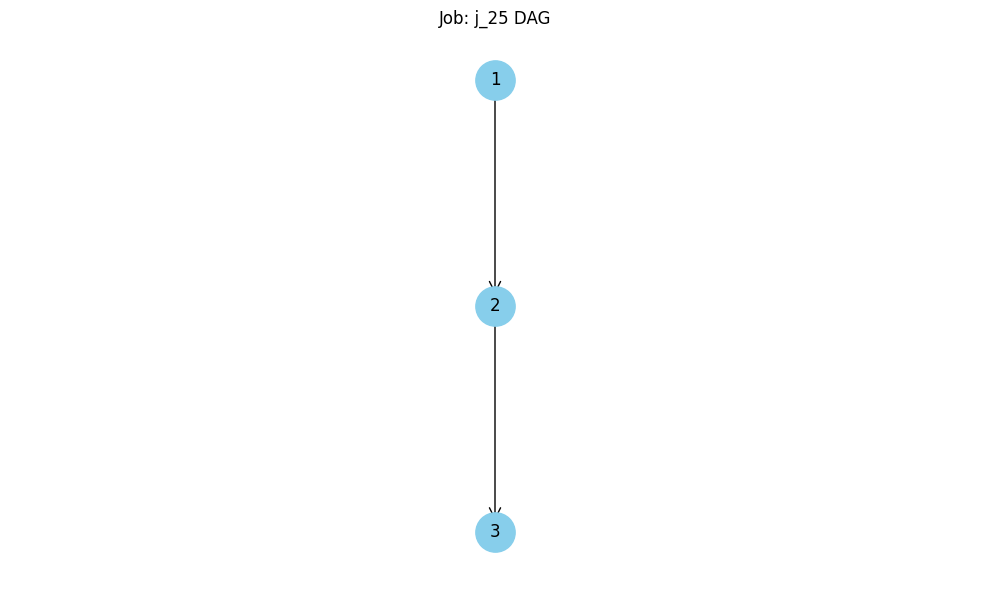

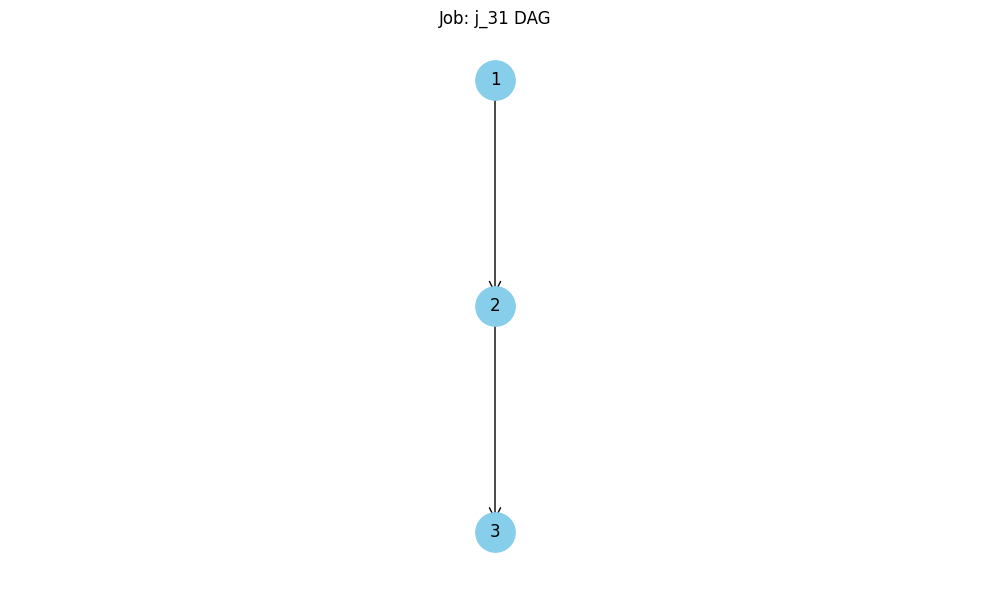

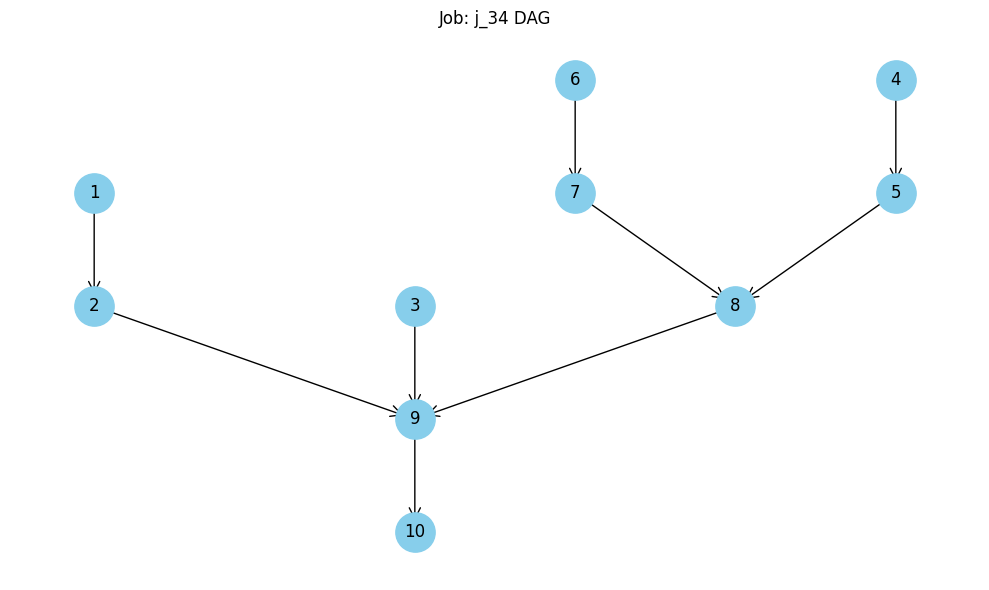

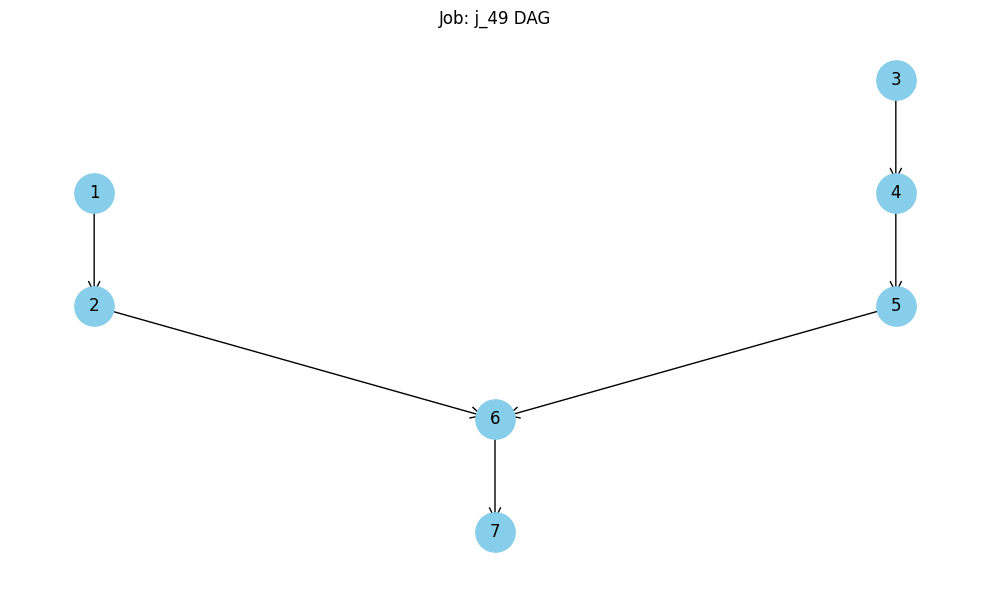

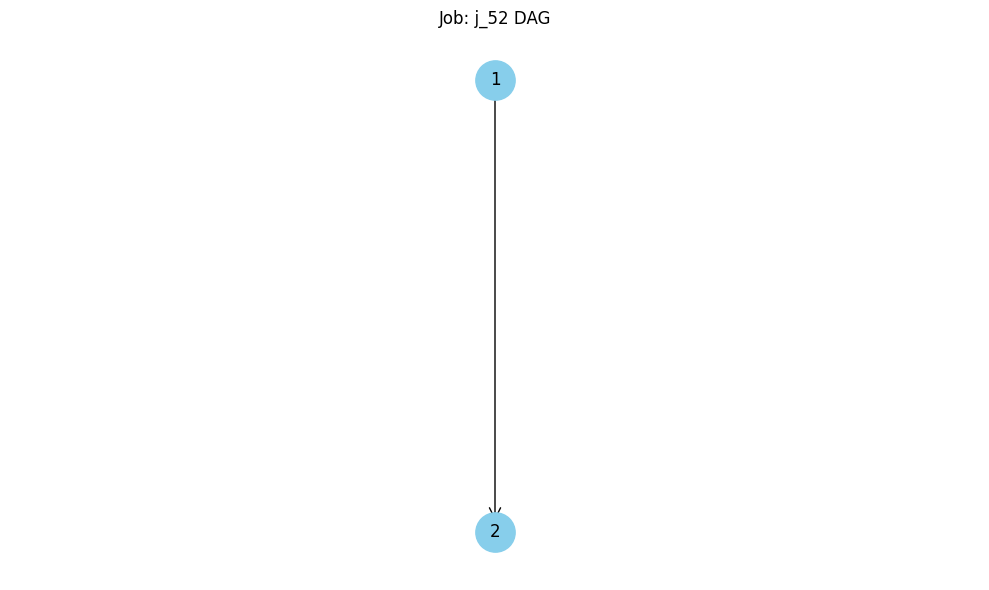

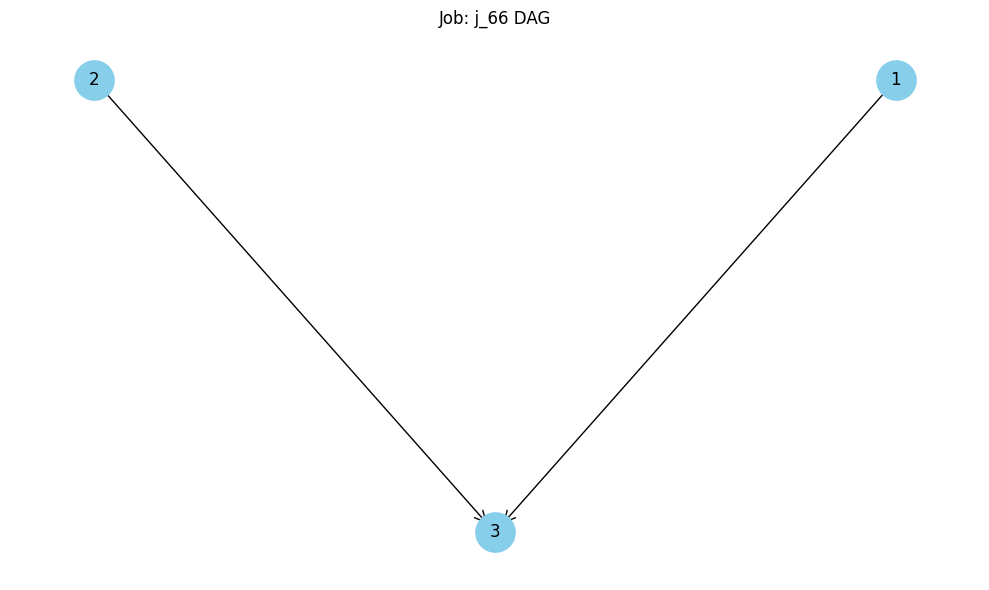

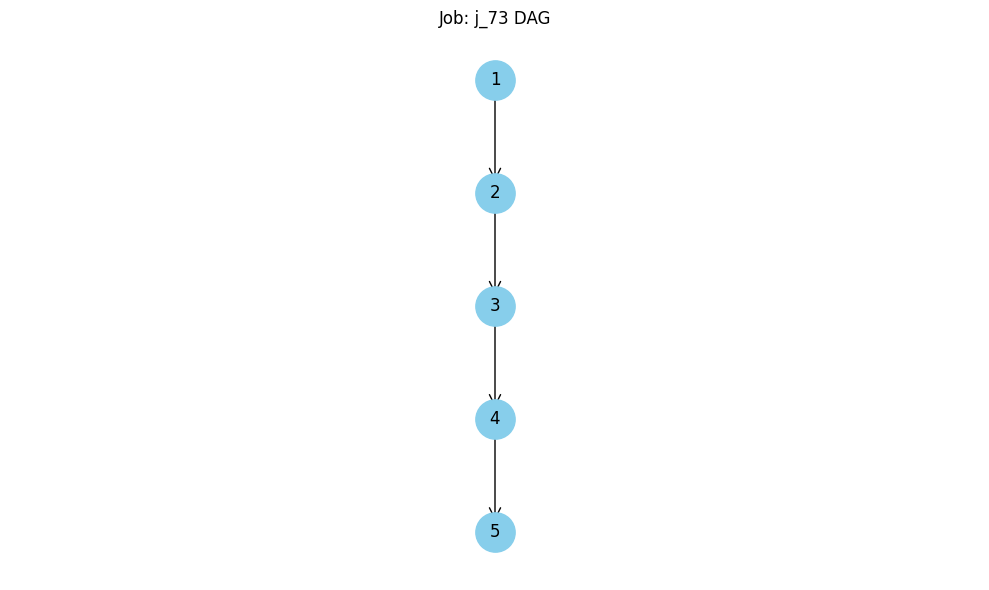

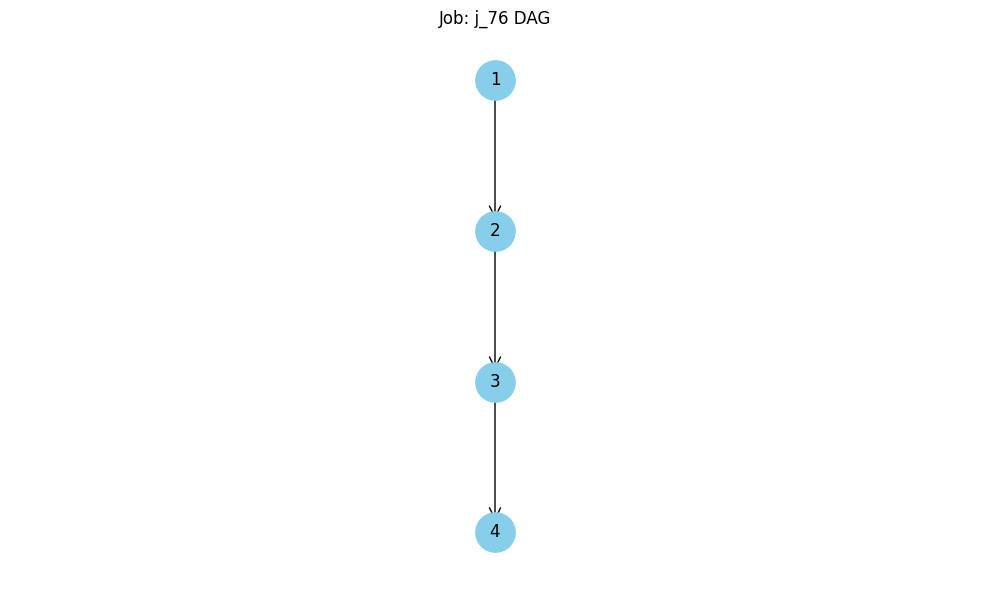

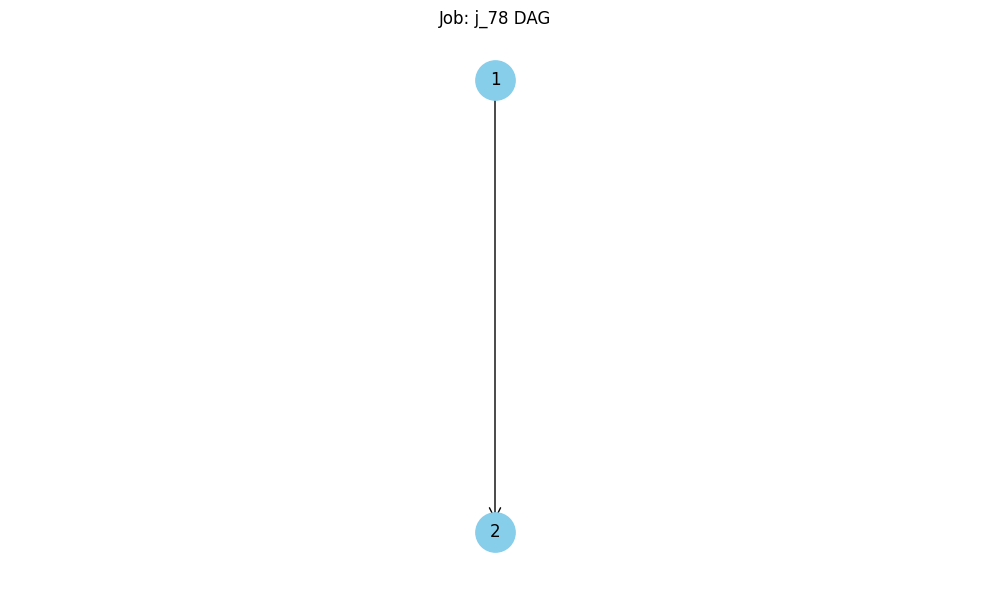

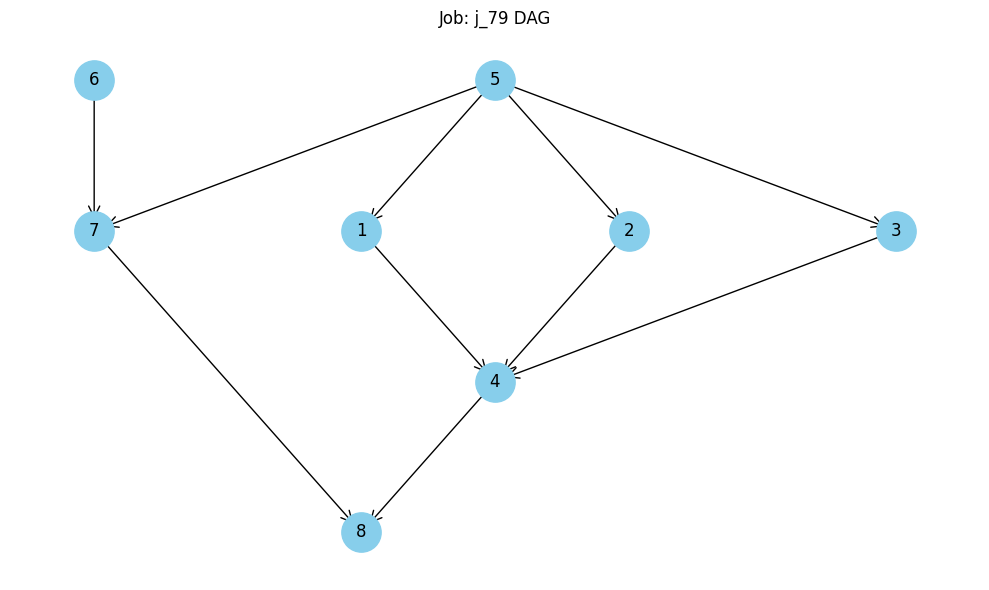

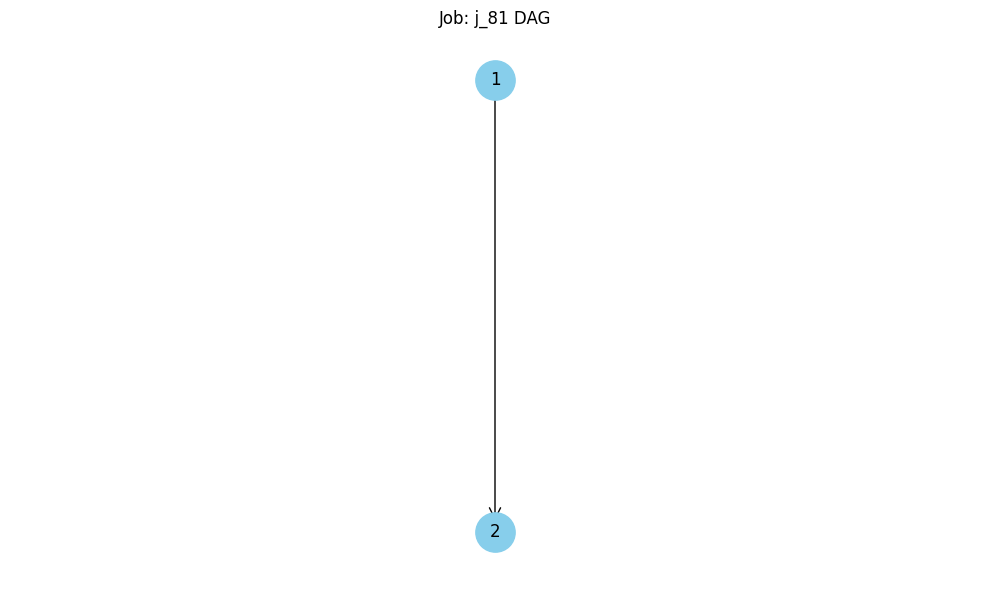

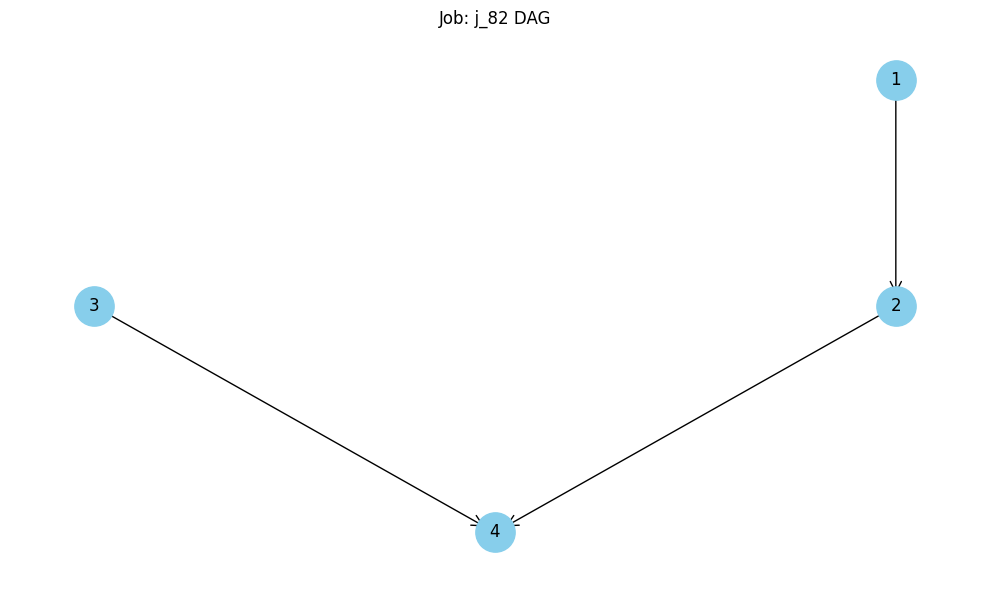

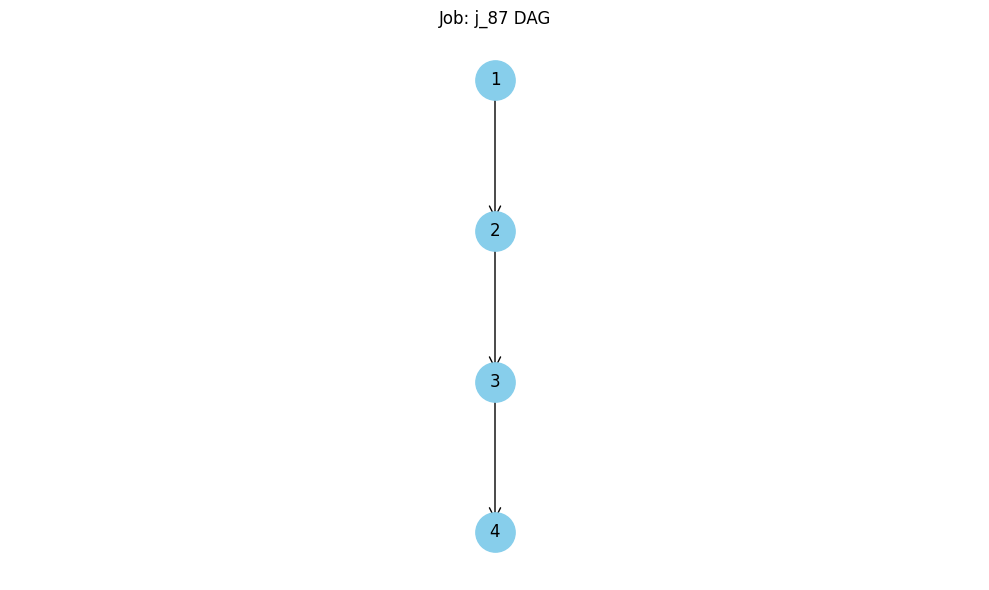

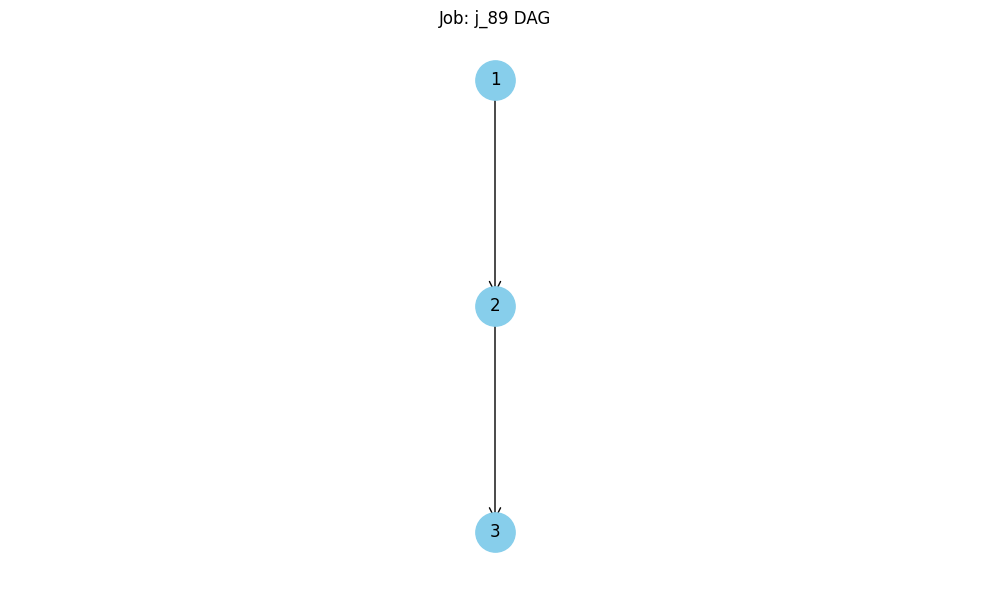

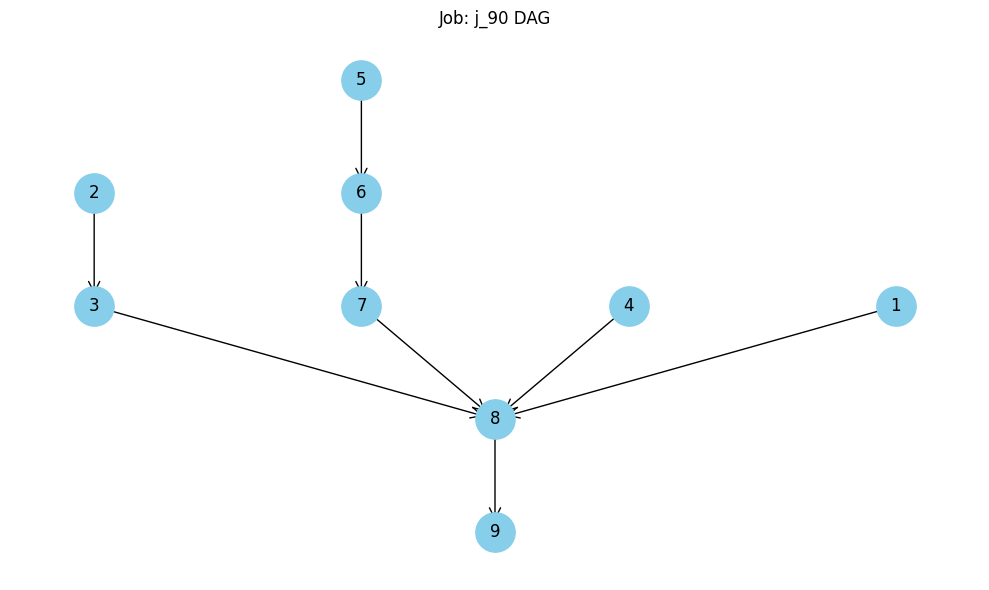

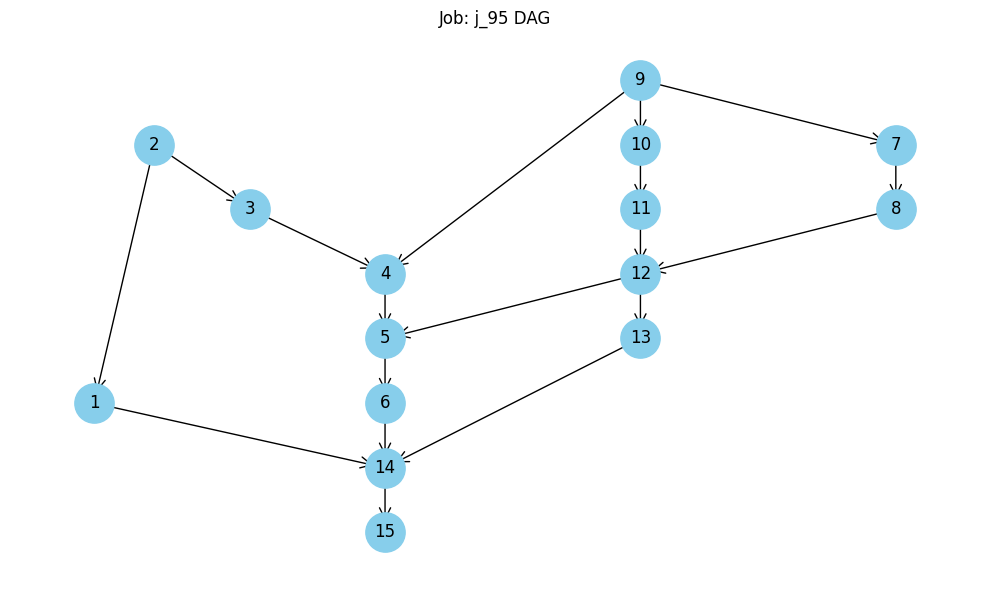

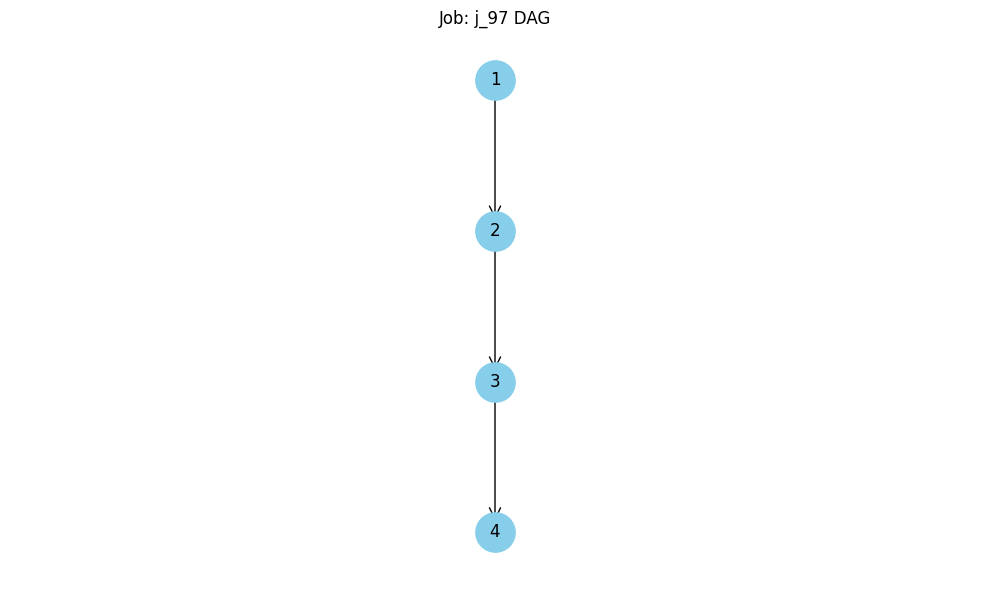

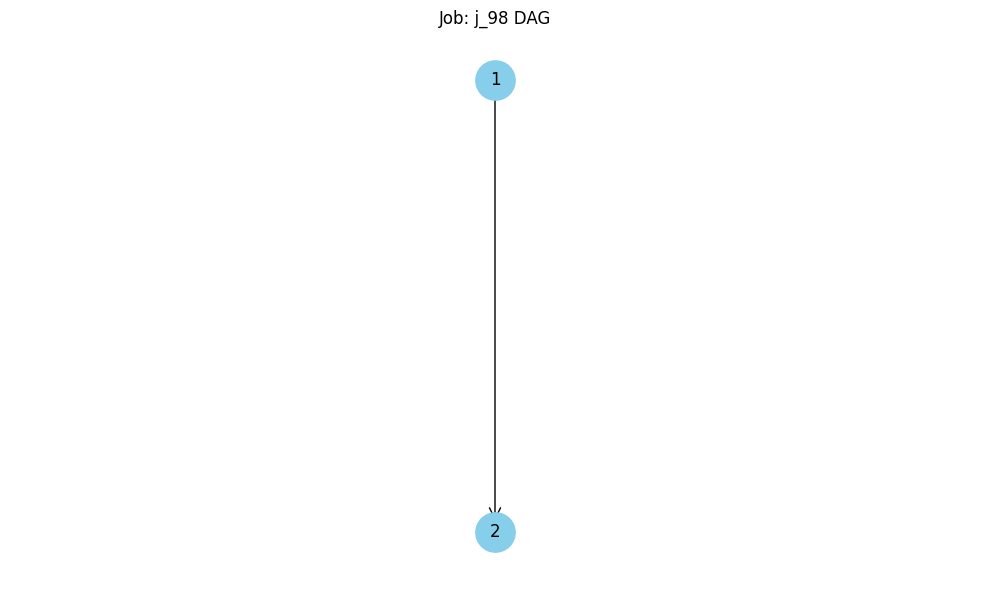

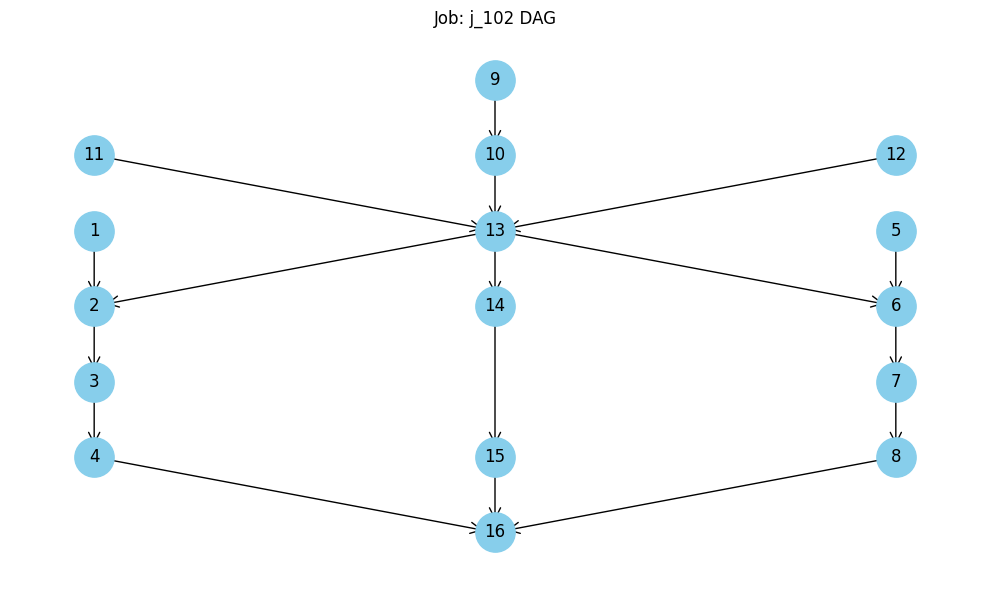

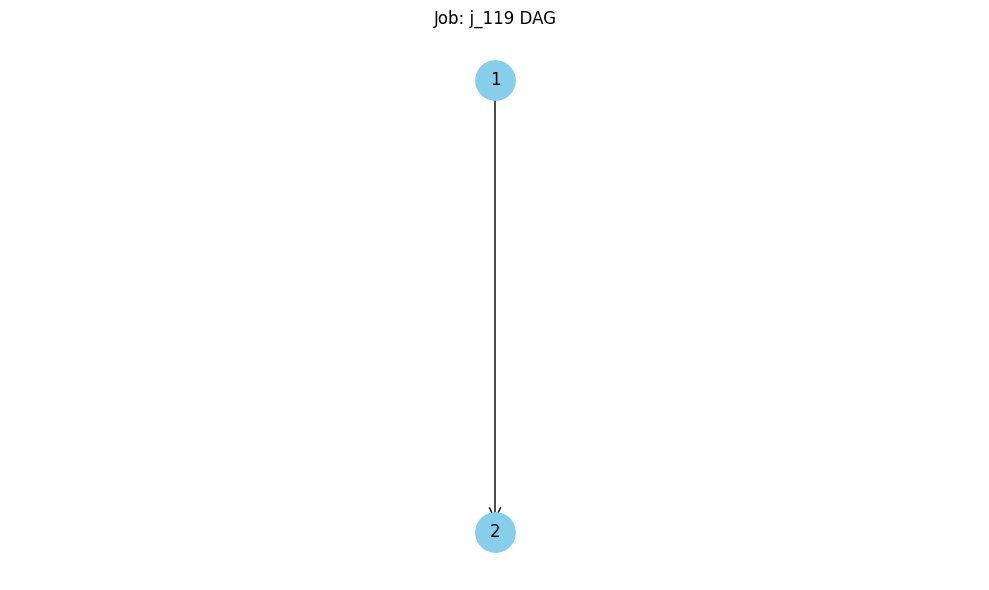

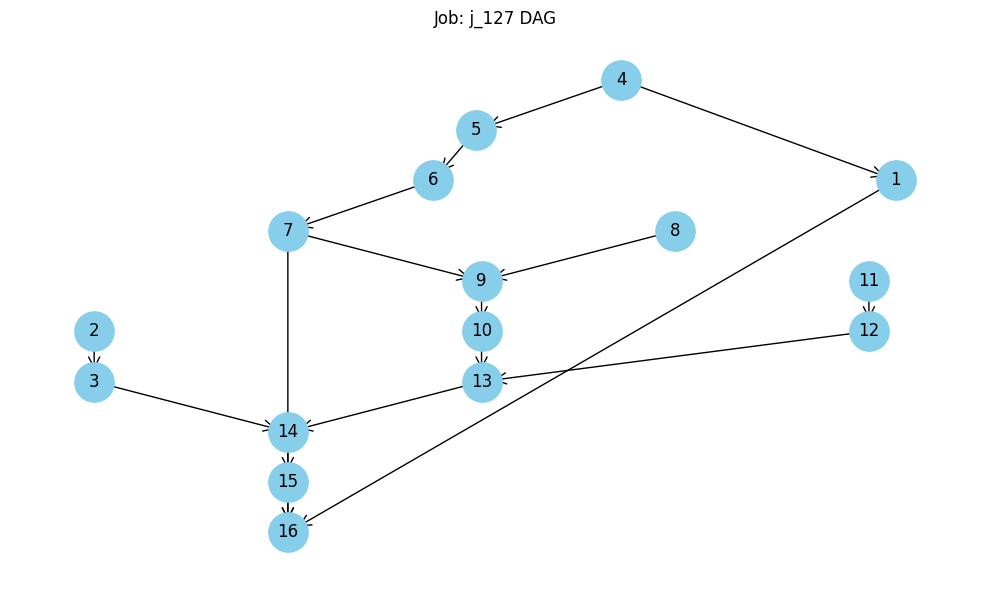

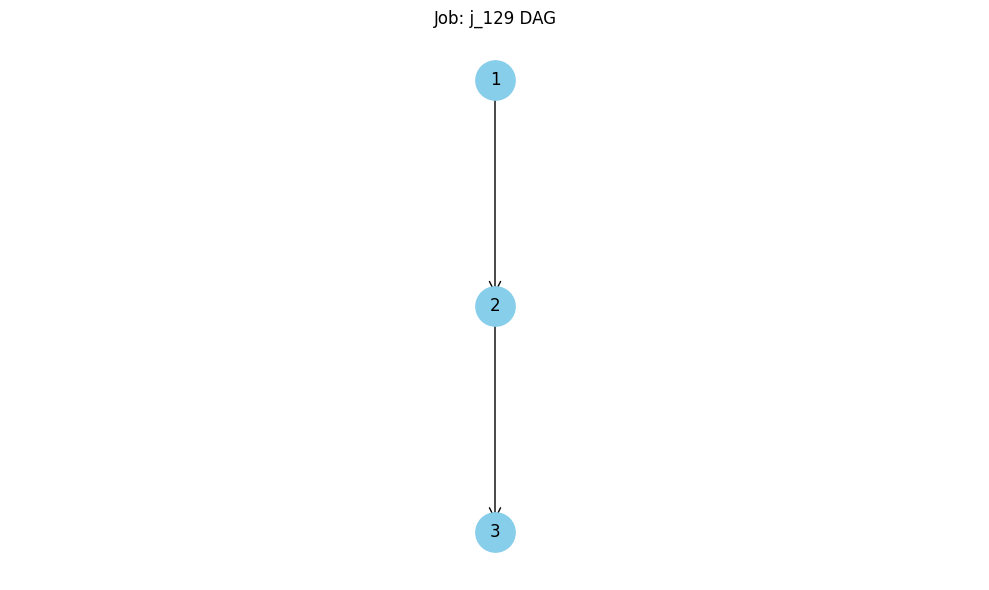

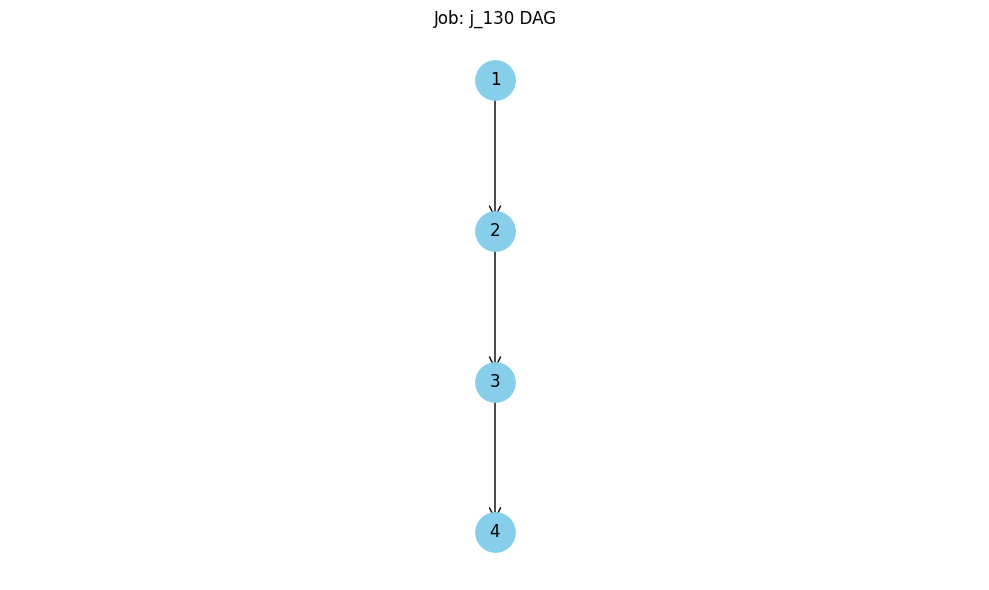

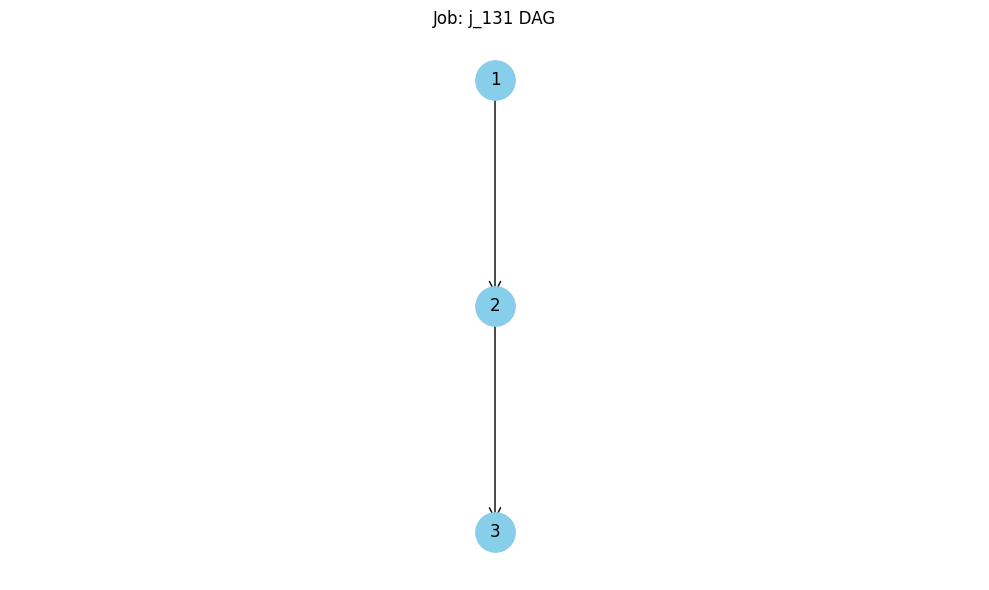

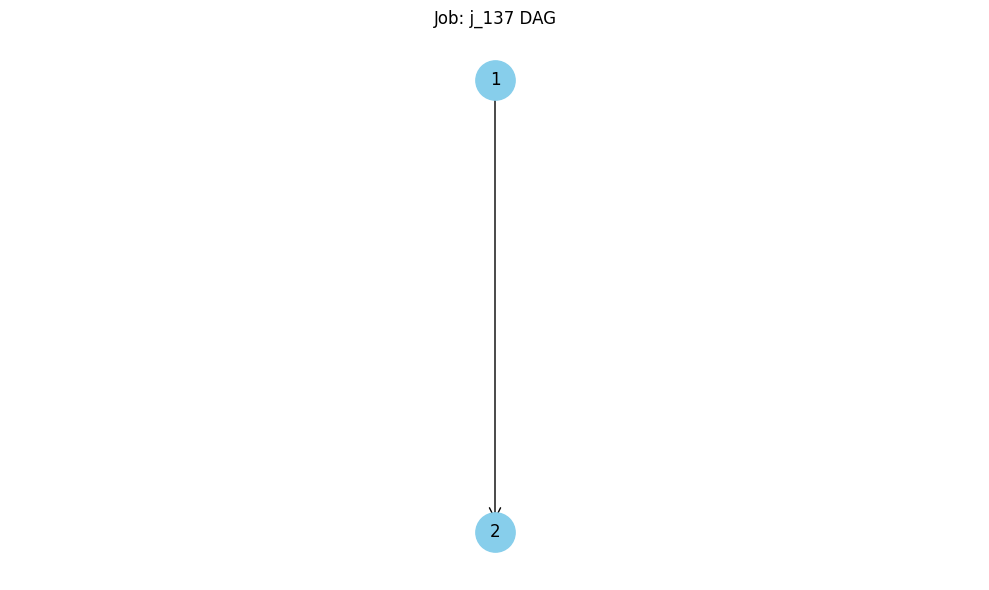

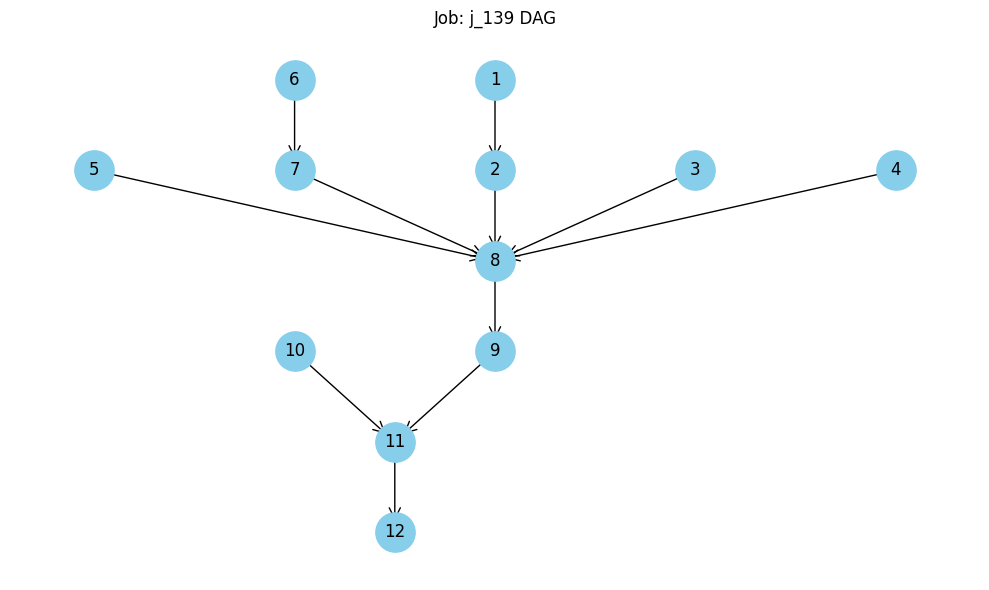

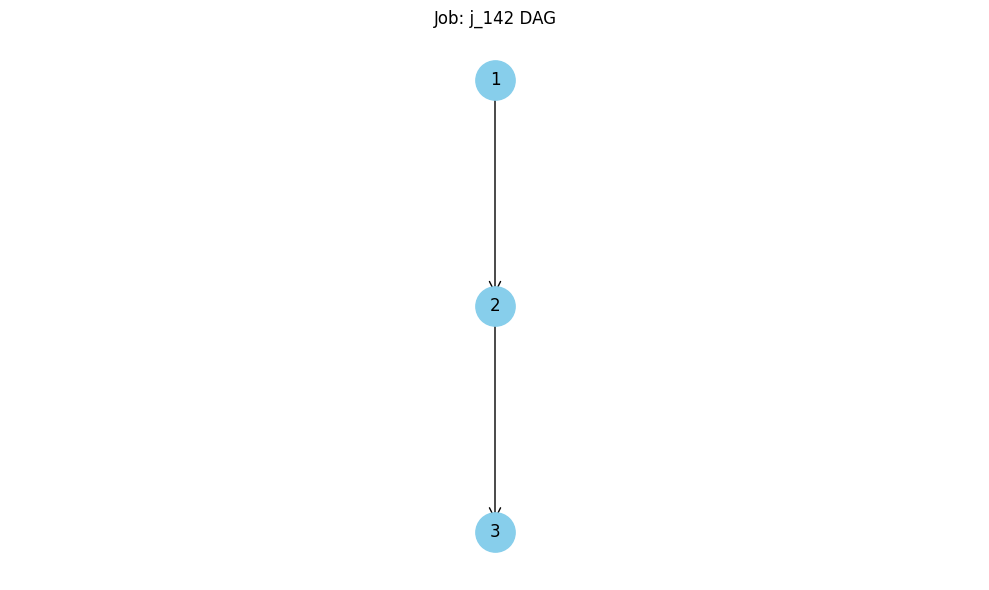

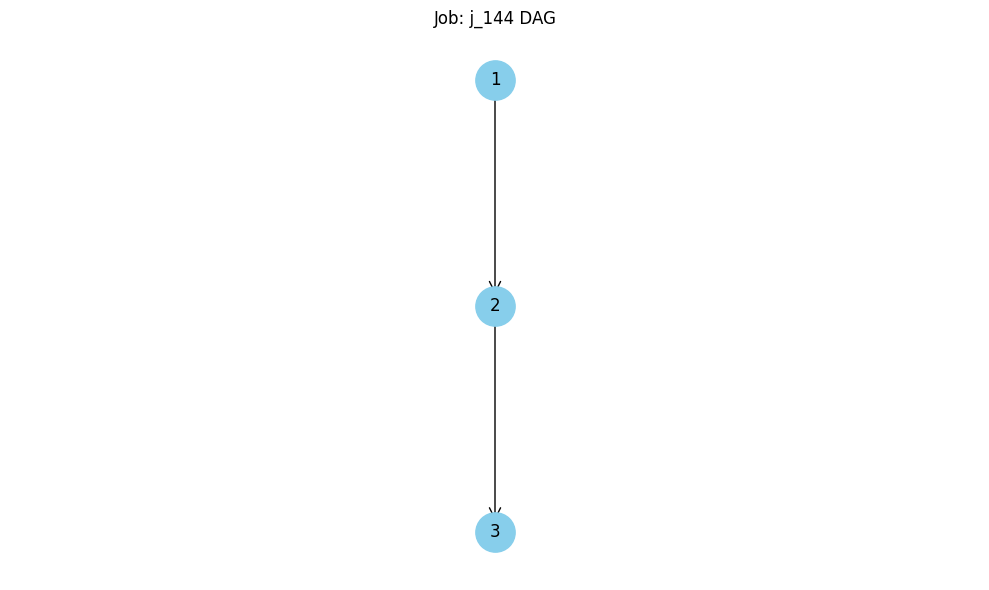

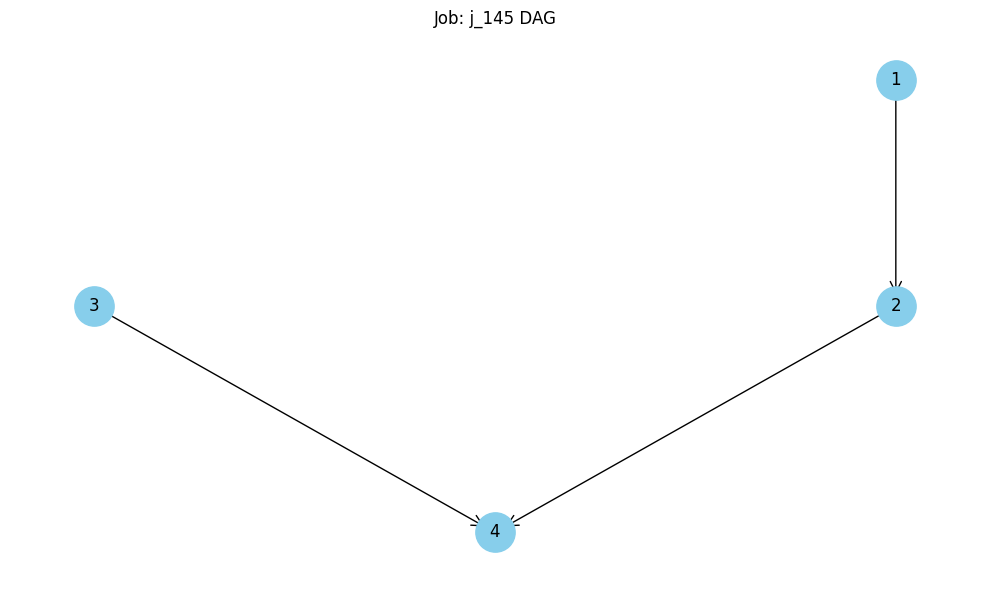

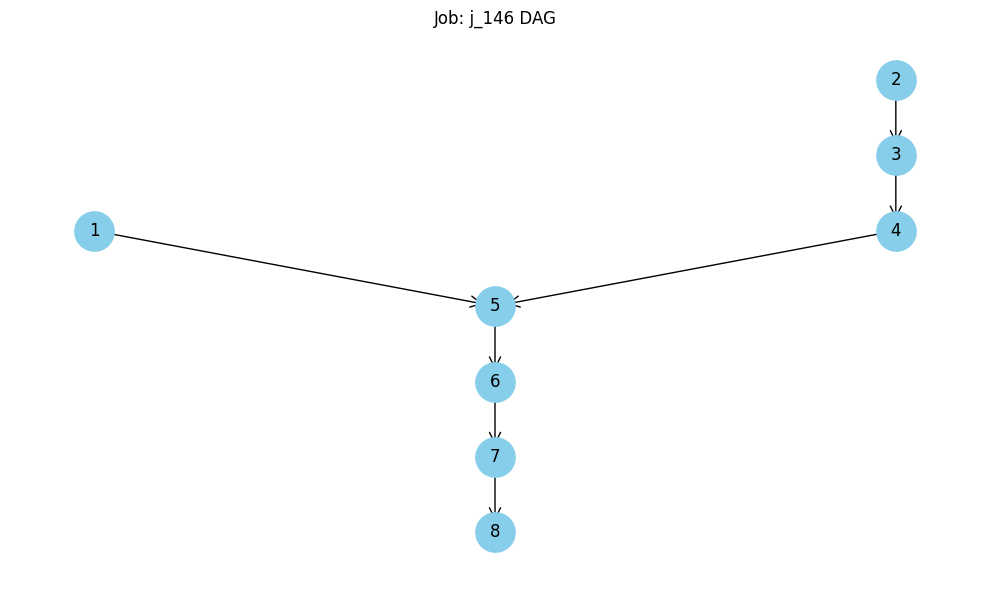

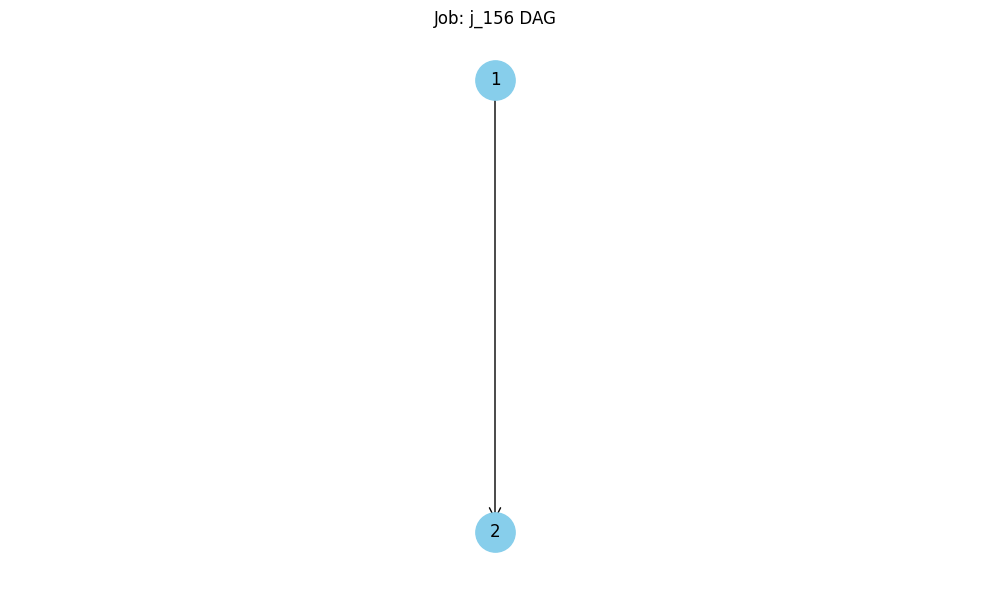

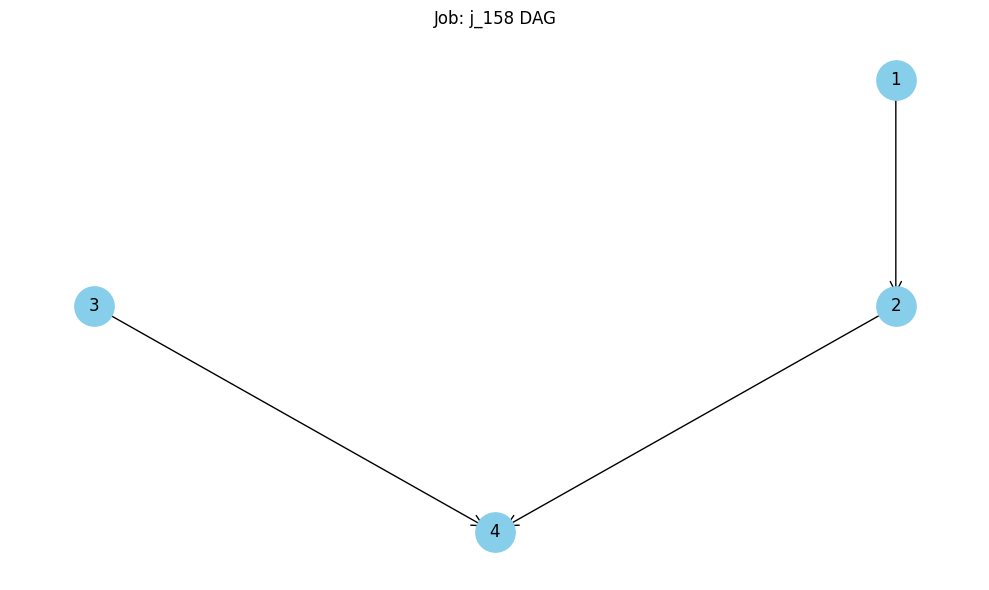

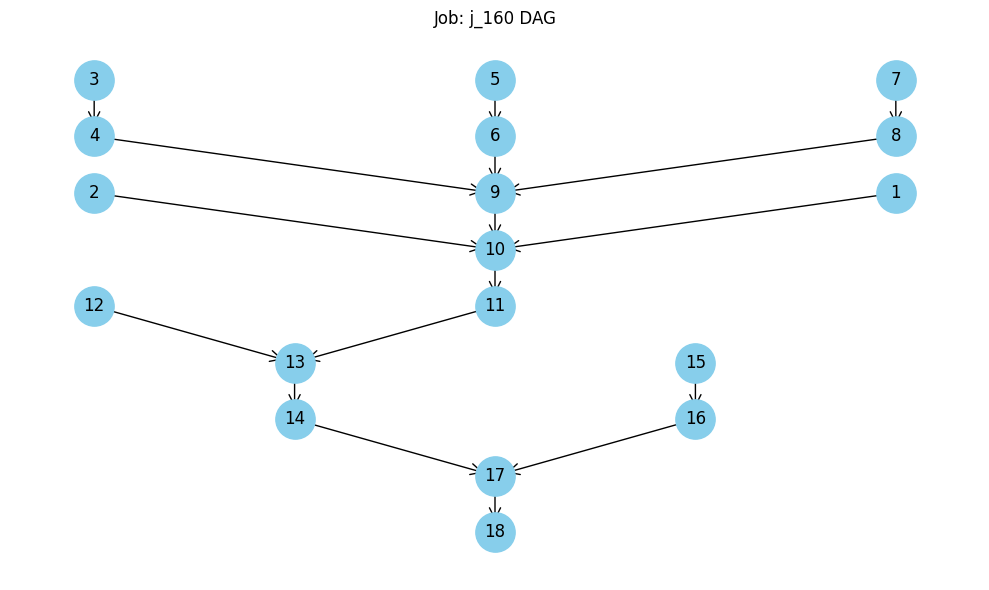

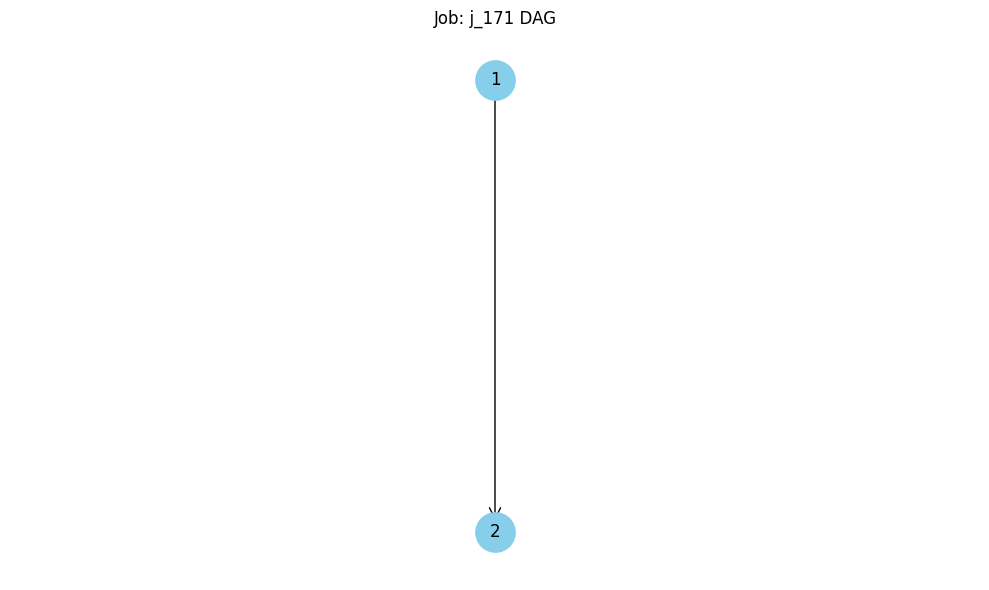

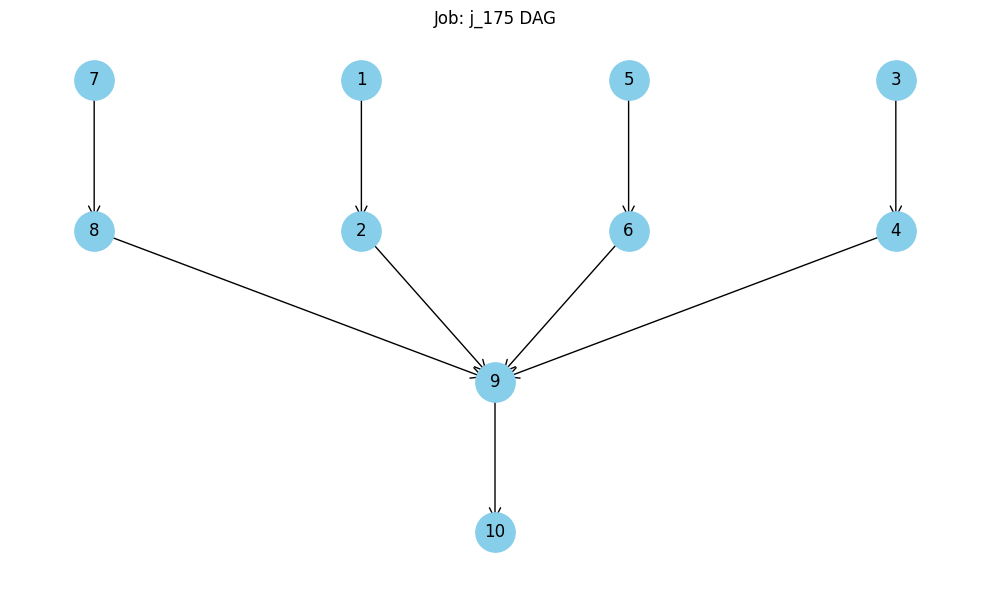

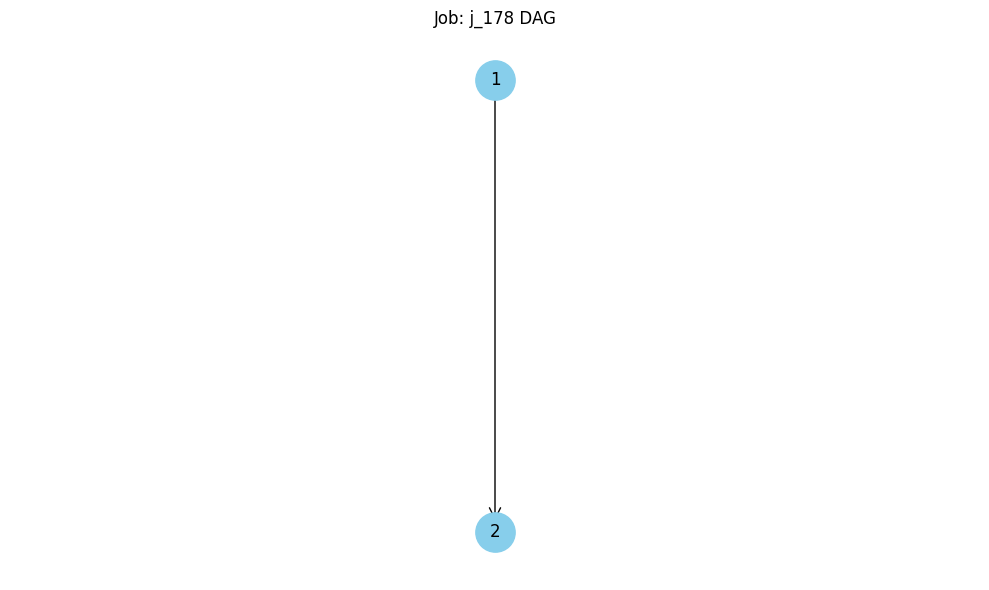

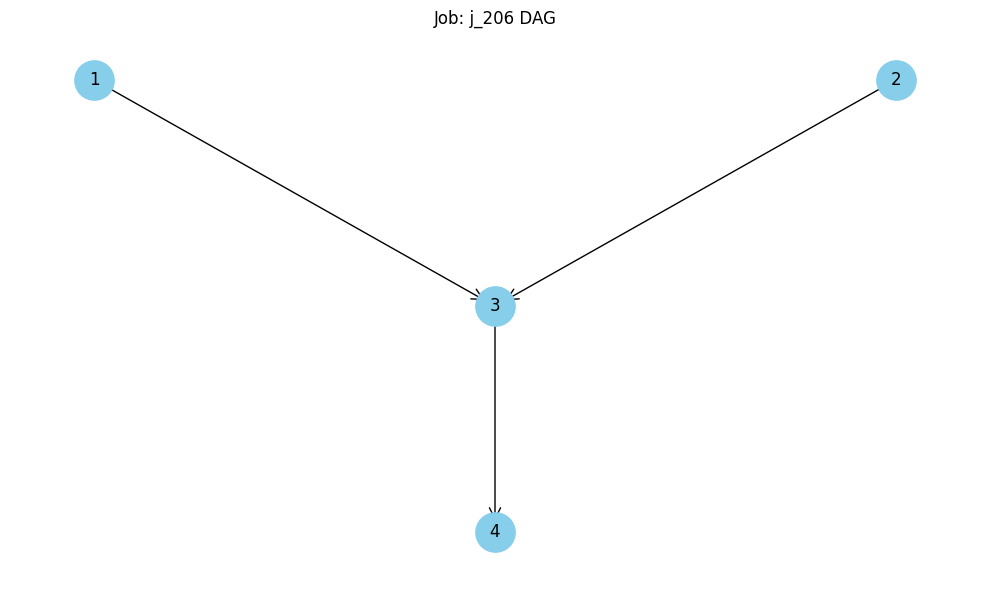

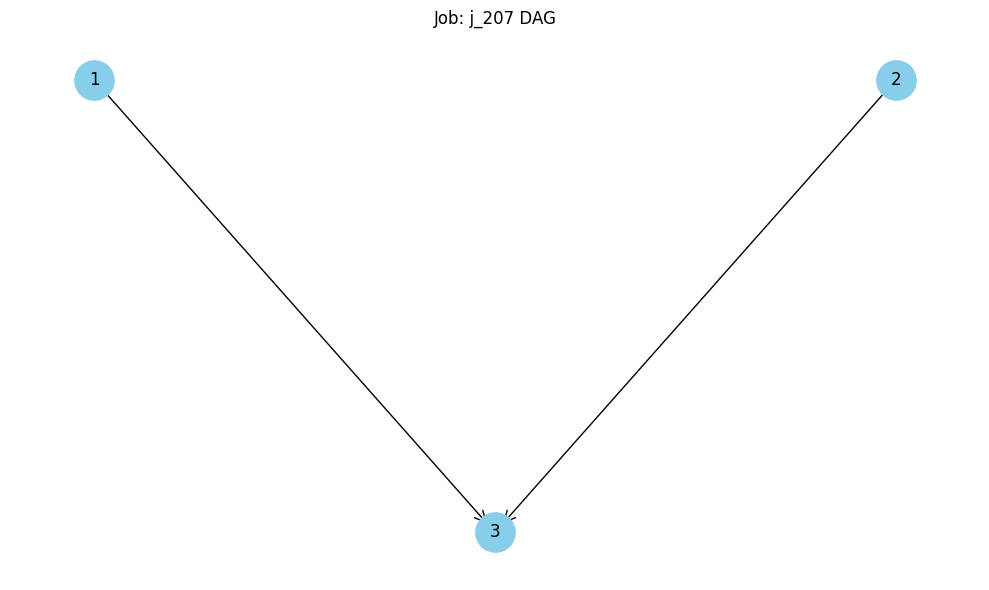

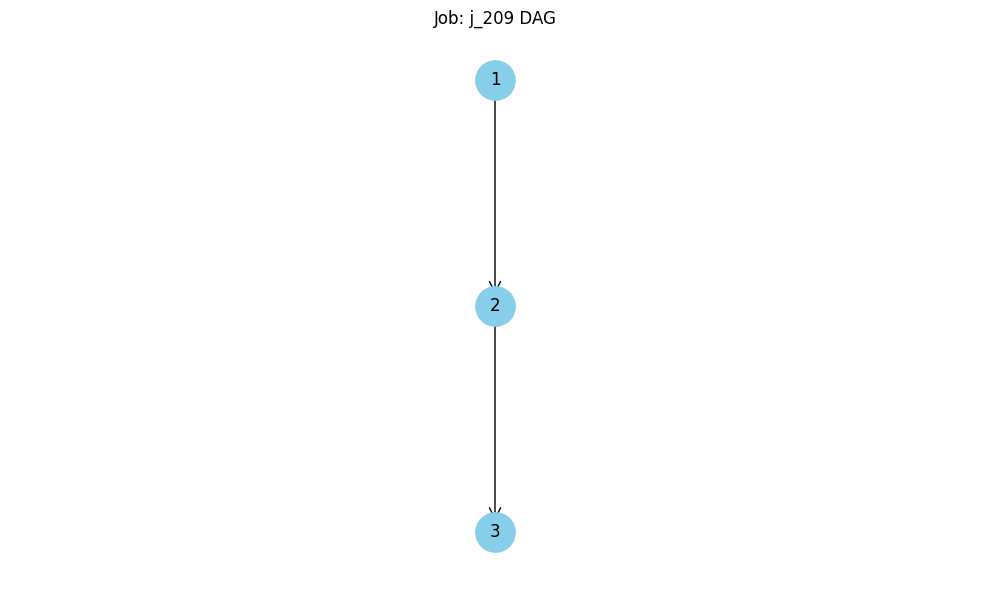

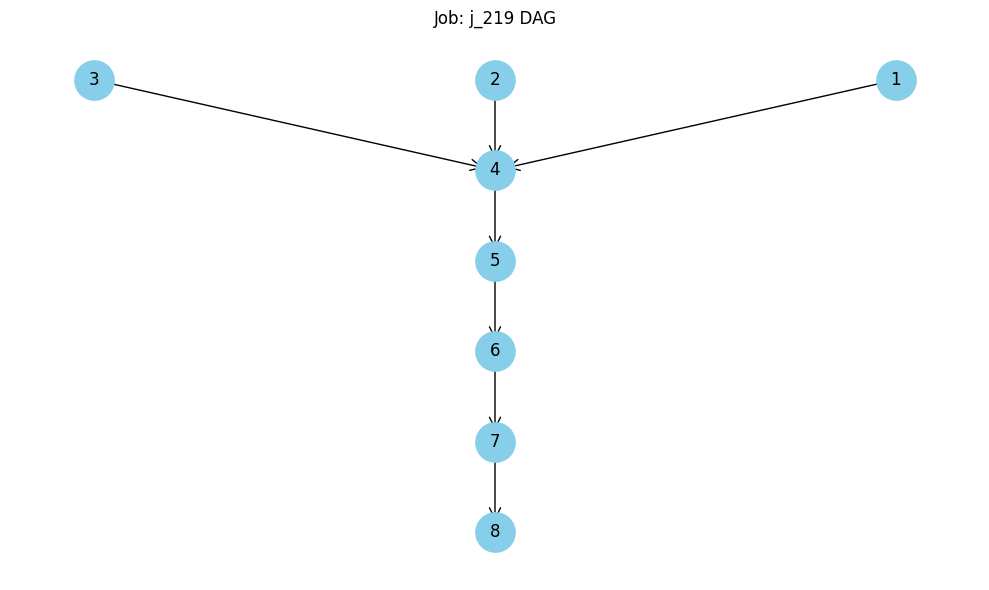

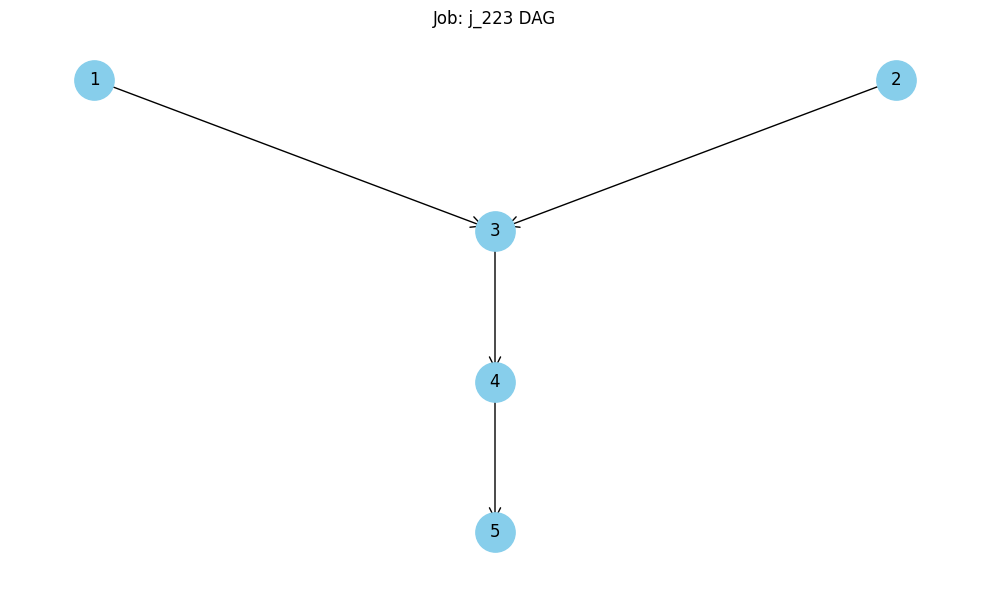

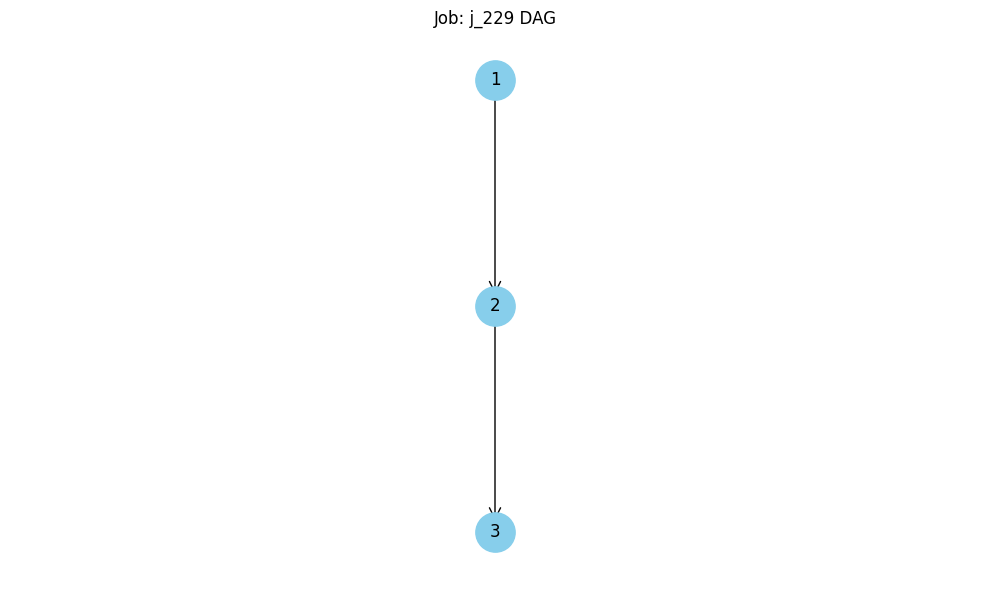

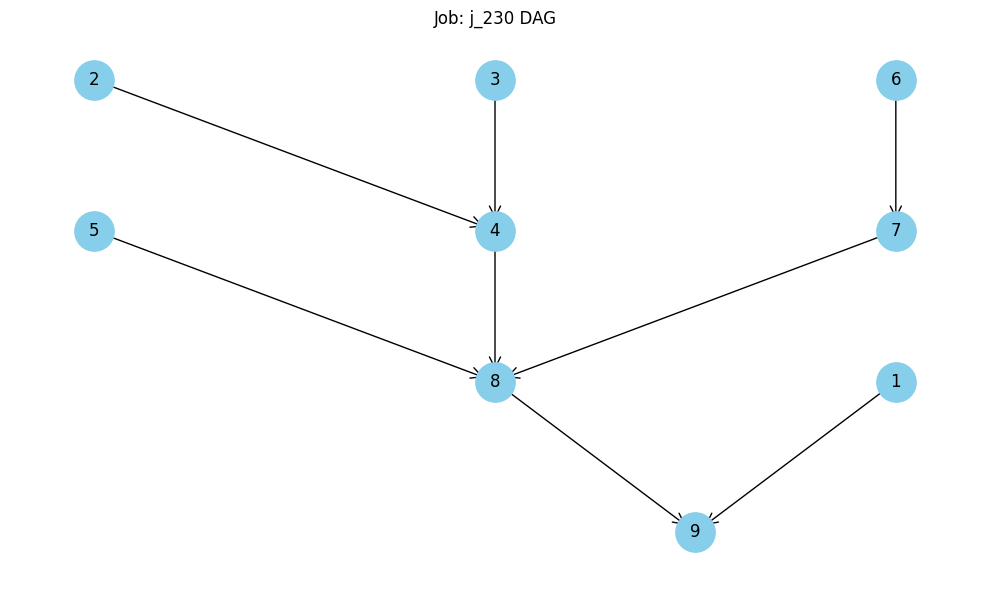

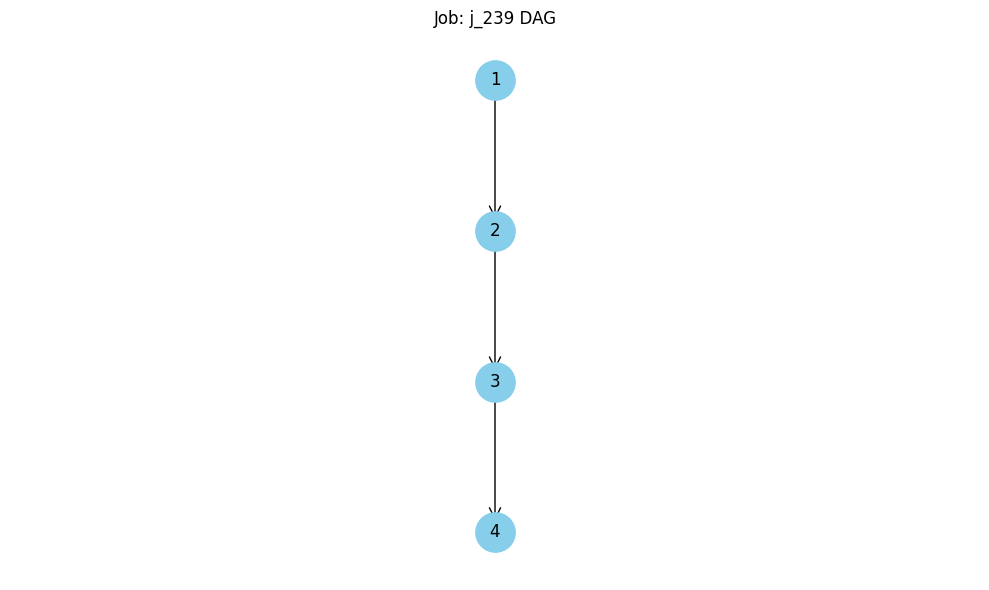

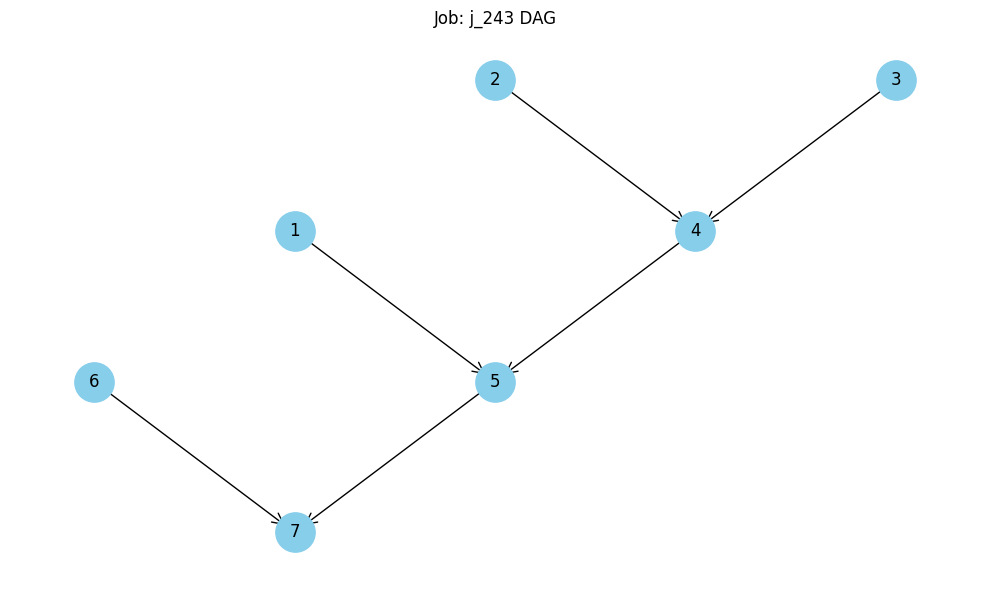

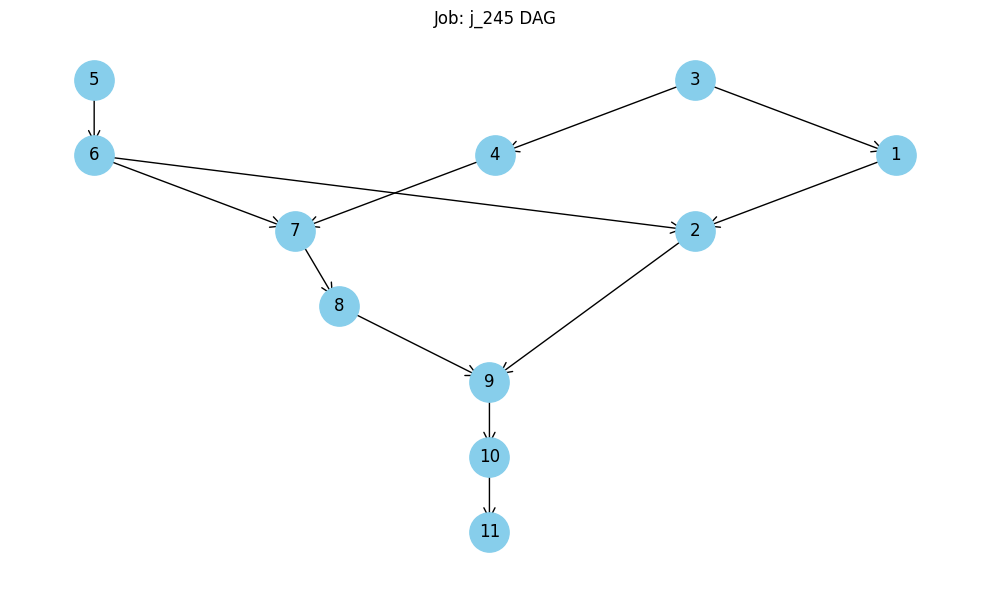

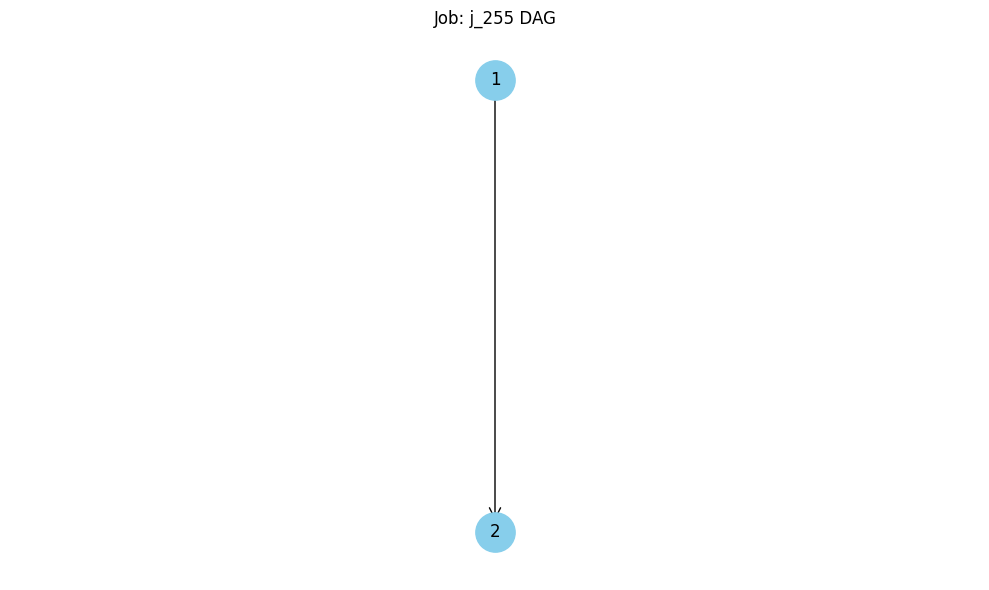

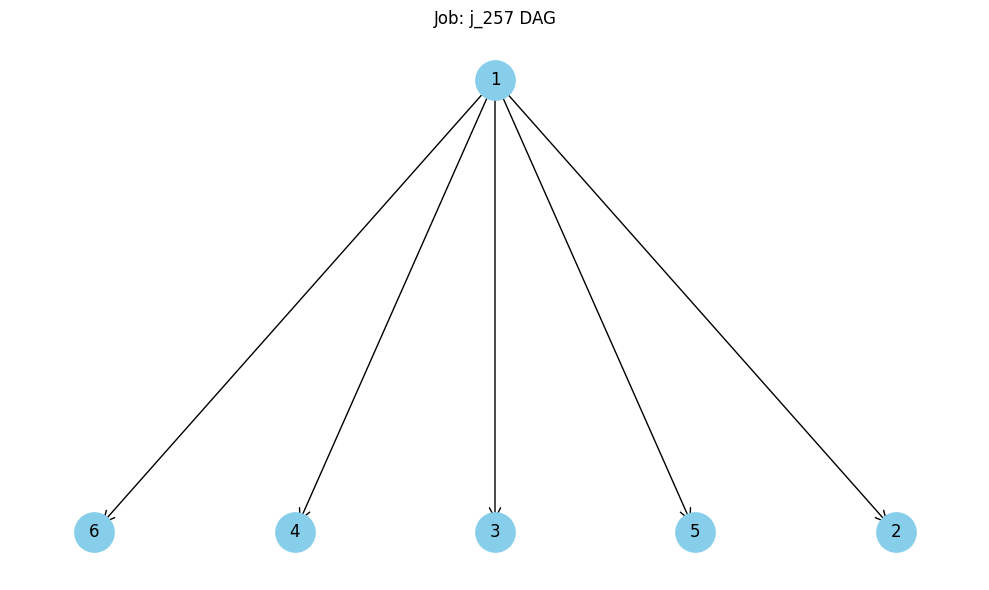

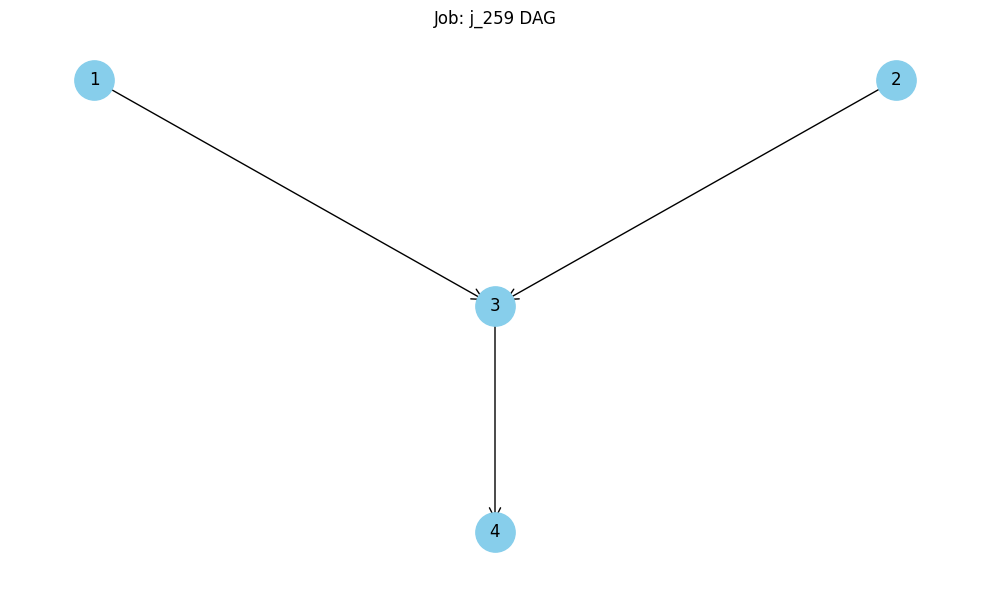

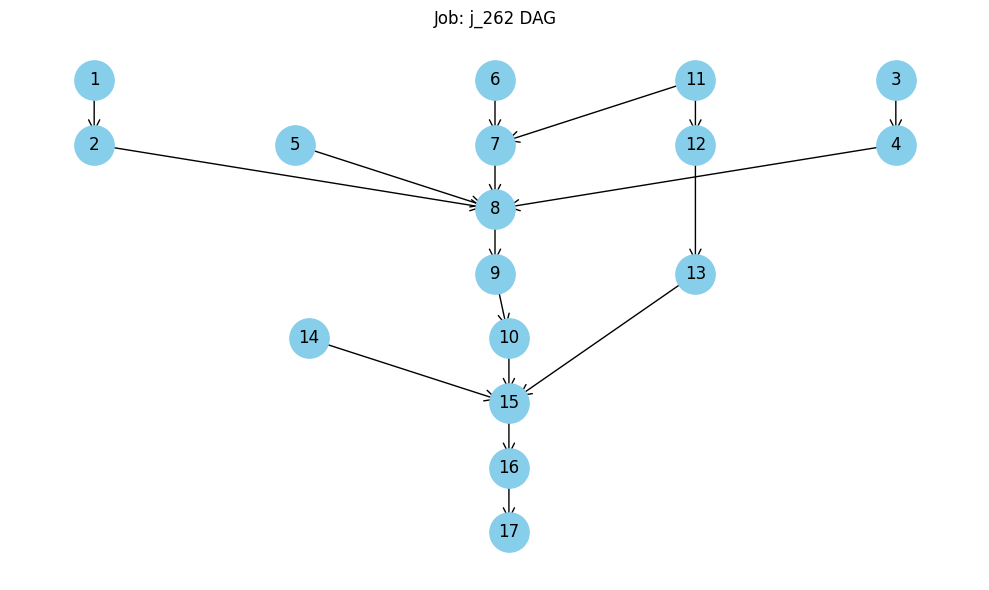

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import re

# 读取 CSV
df = pd.read_csv("batch_task.csv", header=None, names=["task_name", "instance_num", "job_name", "task_type",
                                                       "status", "start_time", "end_time",
                                                       "plan_cpu", "plan_mem"])

# 取前 100 个唯一 job_name
unique_jobs = df['job_name'].unique()[:100]

# 遍历每个 job，构建 DAG
for job in unique_jobs:
    job_df = df[df['job_name'] == job]

    # 如果任务全是随机名的（比如 task_xxx），就跳过，因为它们是独立任务
    if all(job_df['task_name'].str.startswith('task_')):
        continue

    G = nx.DiGraph()

    # 建立节点和依赖关系
    for _, row in job_df.iterrows():
        task_name = row['task_name']
        # 取任务名中所有数字，作为该 task 的 id 和依赖项
        numbers = re.findall(r'\d+', task_name)

        if not numbers:
            continue  # 跳过无数字的任务名

        task_id = numbers[0]
        dependencies = numbers[1:]

        G.add_node(task_id)

        for dep in dependencies:
            G.add_edge(dep, task_id)

    if len(G.nodes) <= 1:
        continue  # 跳过空图

    # 画图
    plt.figure(figsize=(10, 6))
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    nx.draw_networkx_nodes(G, pos, node_size=800, node_color='skyblue')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=12)

    plt.title(f"Job: {job} DAG")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [1]:
# ...existing code...
import pandas as pd

# 读取 CSV
df = pd.read_csv("batch_task.csv", header=None, names=["task_name", "instance_num", "job_name", "task_type", "status", "start_time", "end_time", "plan_cpu", "plan_mem"])

# 1. 统计每个 job_name 包含多少行（即多少个 task/节点）
job_node_counts = df.groupby("job_name").size()

# 2. 筛选出节点数为 5, 10, 15, 20 的 job 数量
targets = [5, 10, 15, 20]

print("-" * 30)
print("Job 节点数统计:")
print("-" * 30)

for t in targets:
    # 统计等于特定数量的 job 个数
    count = (job_node_counts == t).sum()
    print(f"节点数 = {t} 的 Job 数量: {count}")

print("-" * 30)

------------------------------
Job 节点数统计:
------------------------------
节点数 = 5 的 Job 数量: 185346
节点数 = 10 的 Job 数量: 40368
节点数 = 15 的 Job 数量: 15877
节点数 = 20 的 Job 数量: 4795
------------------------------


正在筛选和构建DAG...
筛选完成。
节点数 5: 找到了 10 种不同结构的图
节点数 10: 找到了 10 种不同结构的图
节点数 15: 找到了 10 种不同结构的图
节点数 20: 找到了 10 种不同结构的图


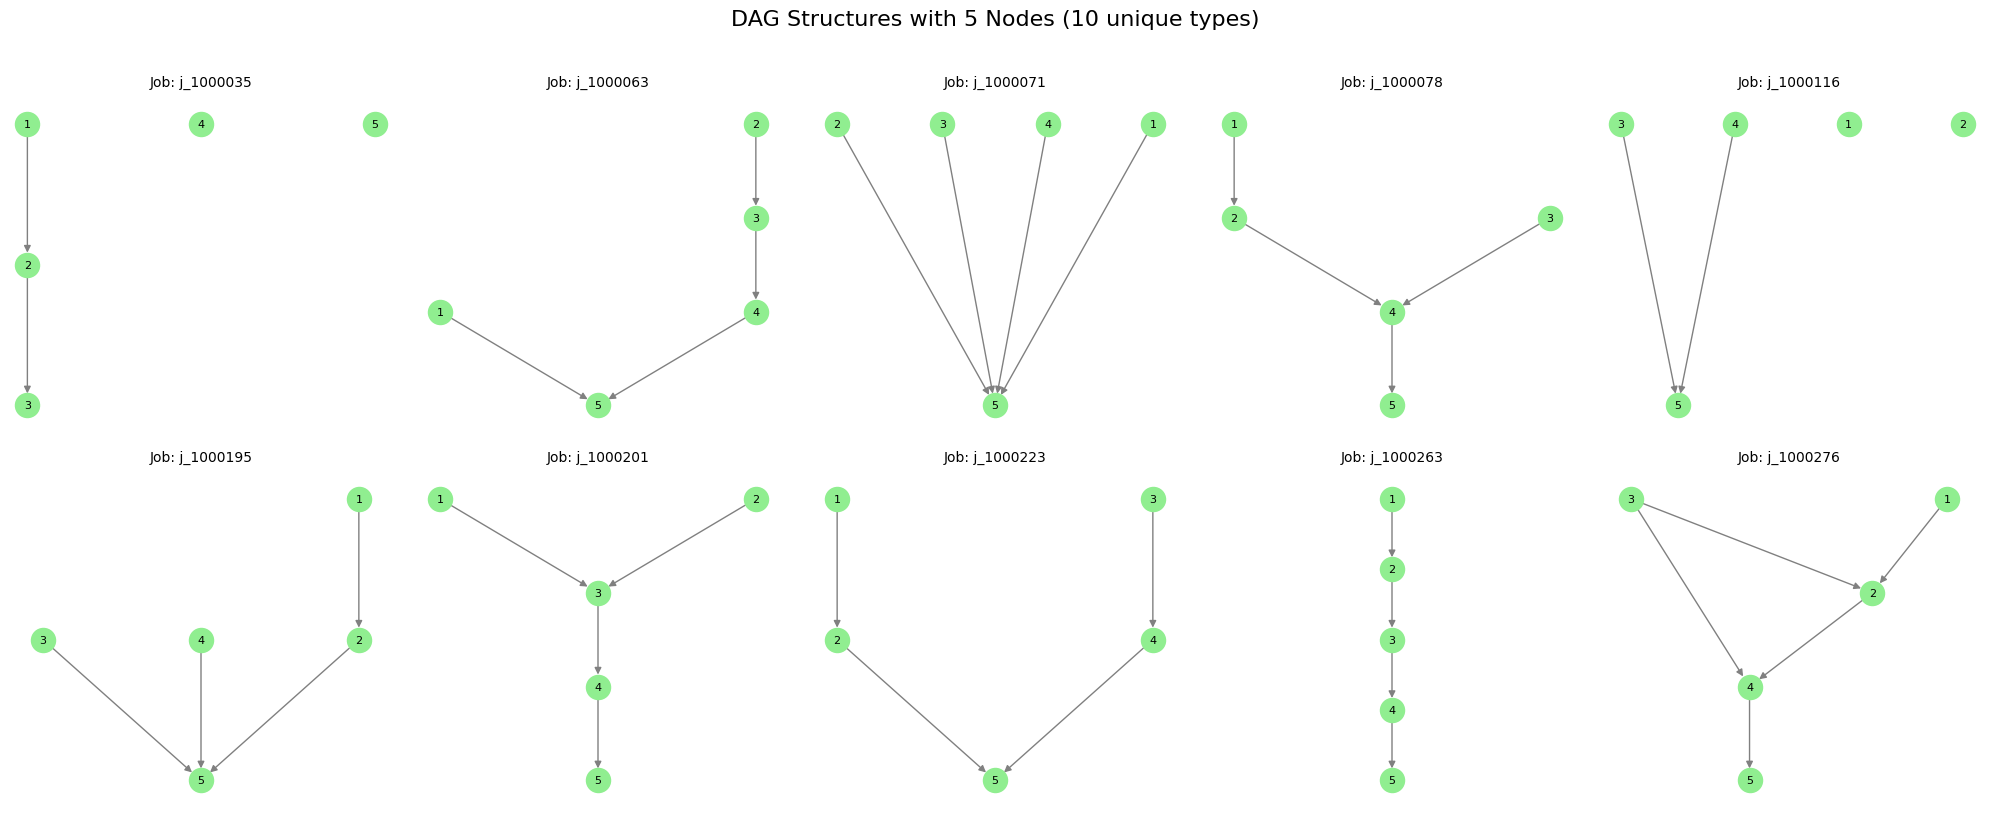

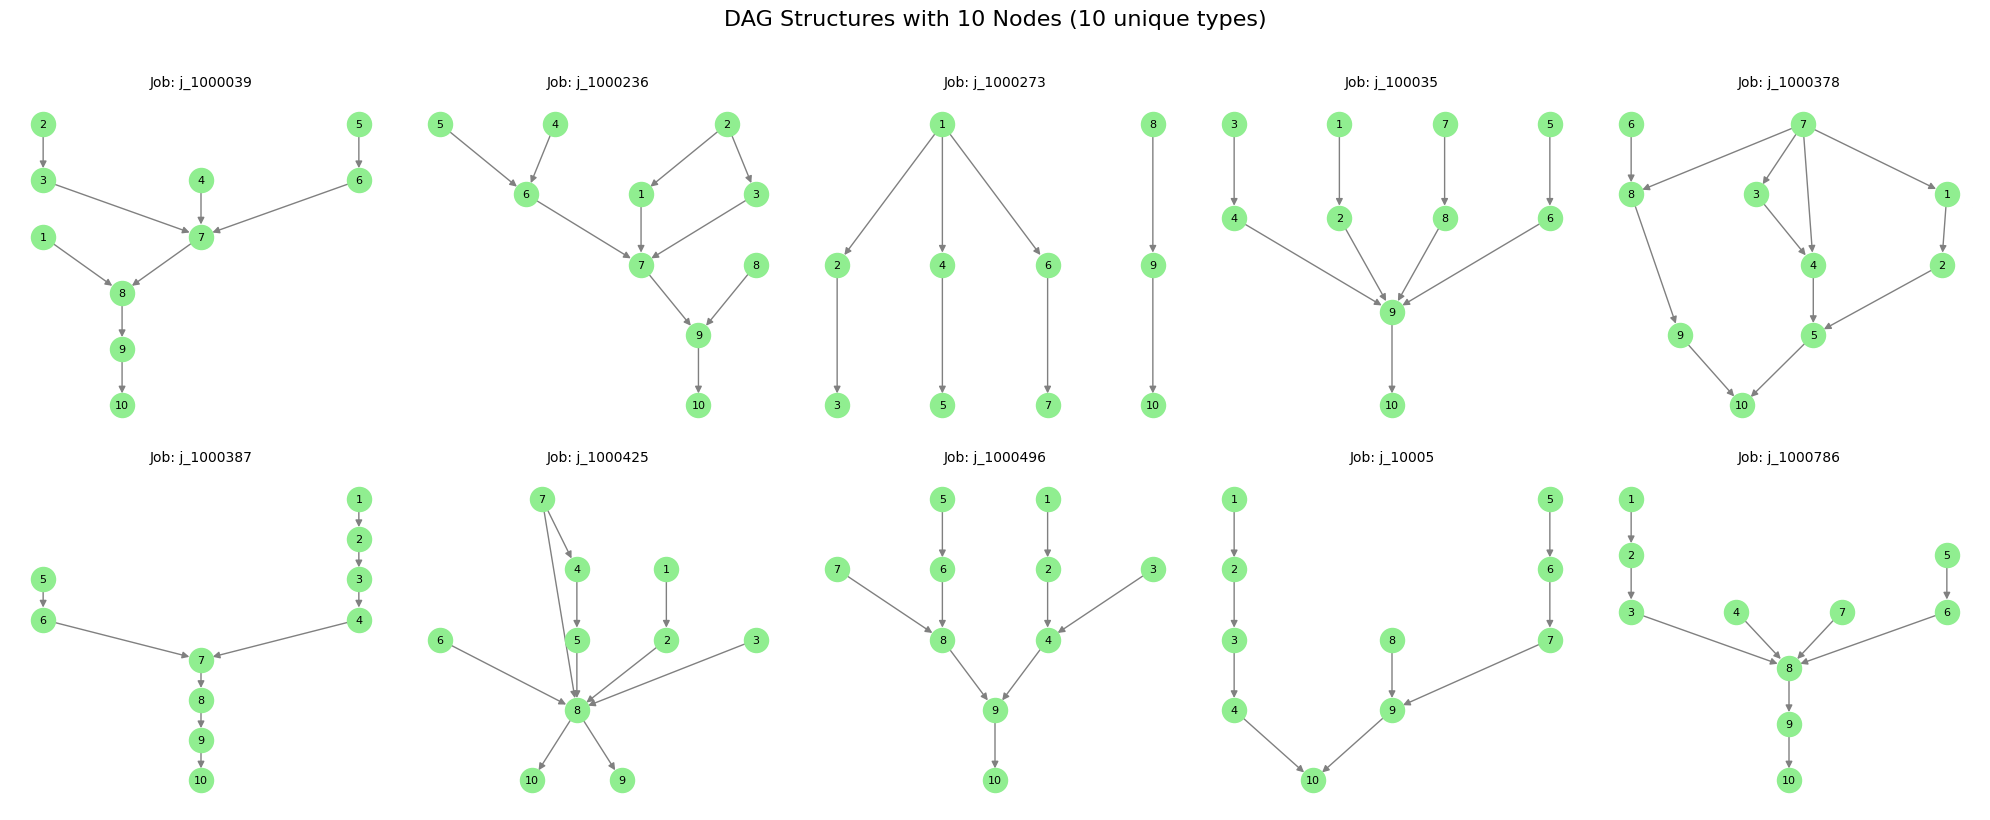

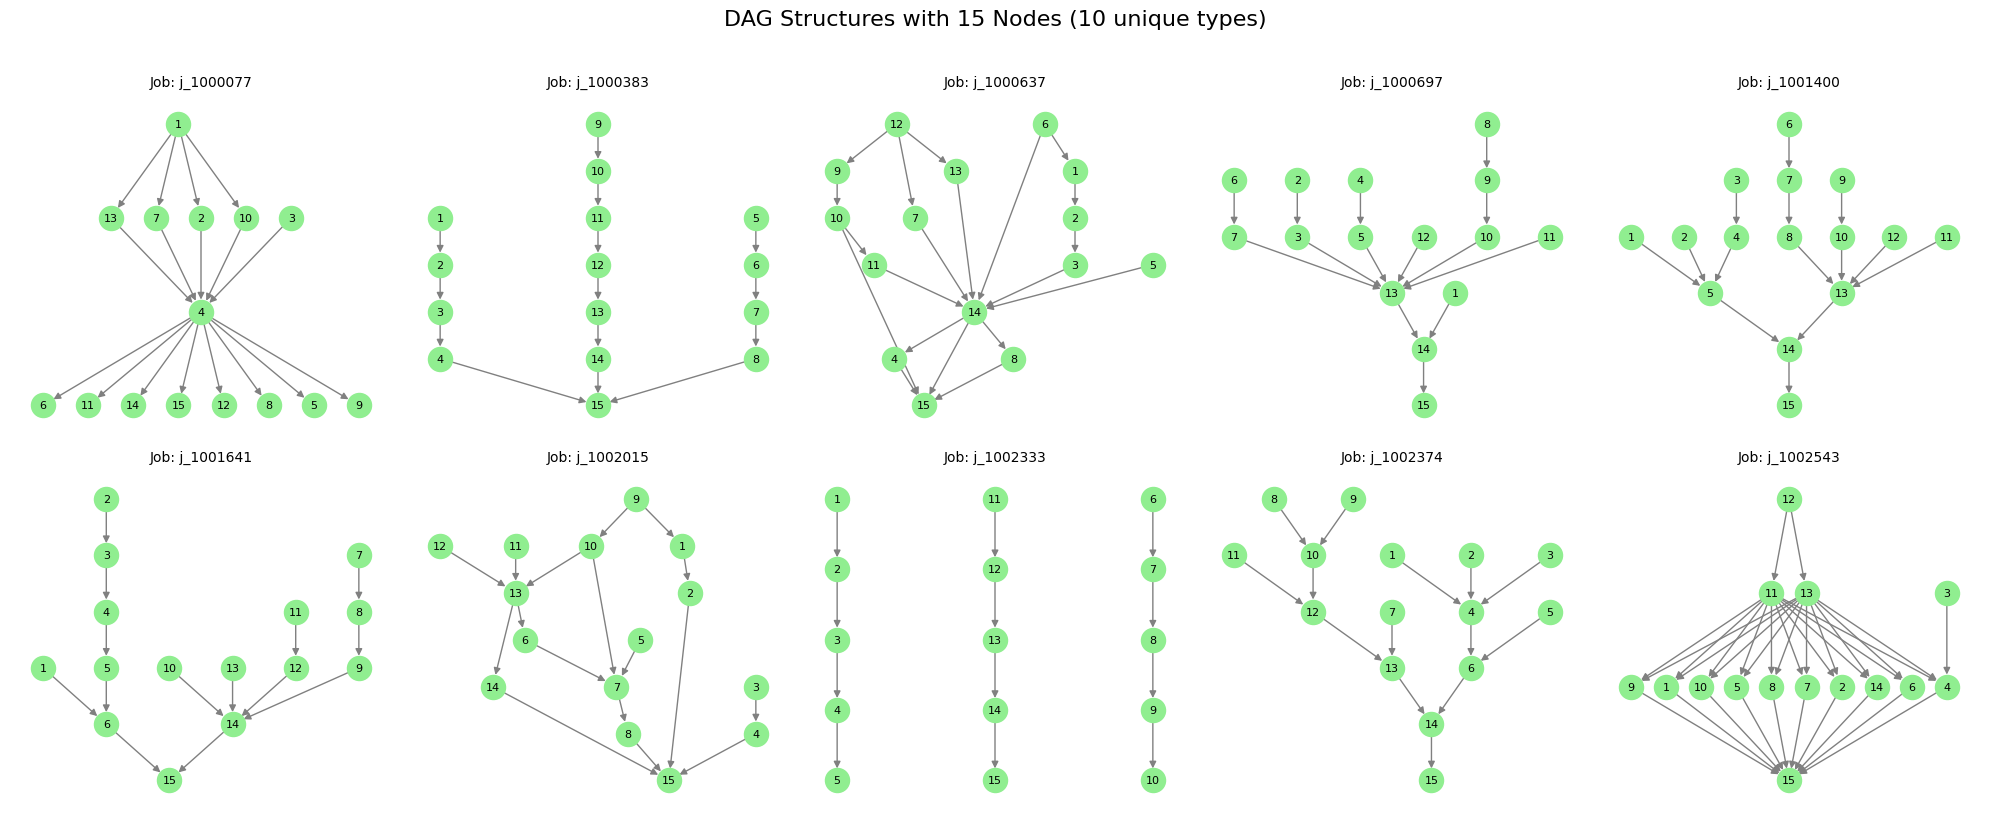

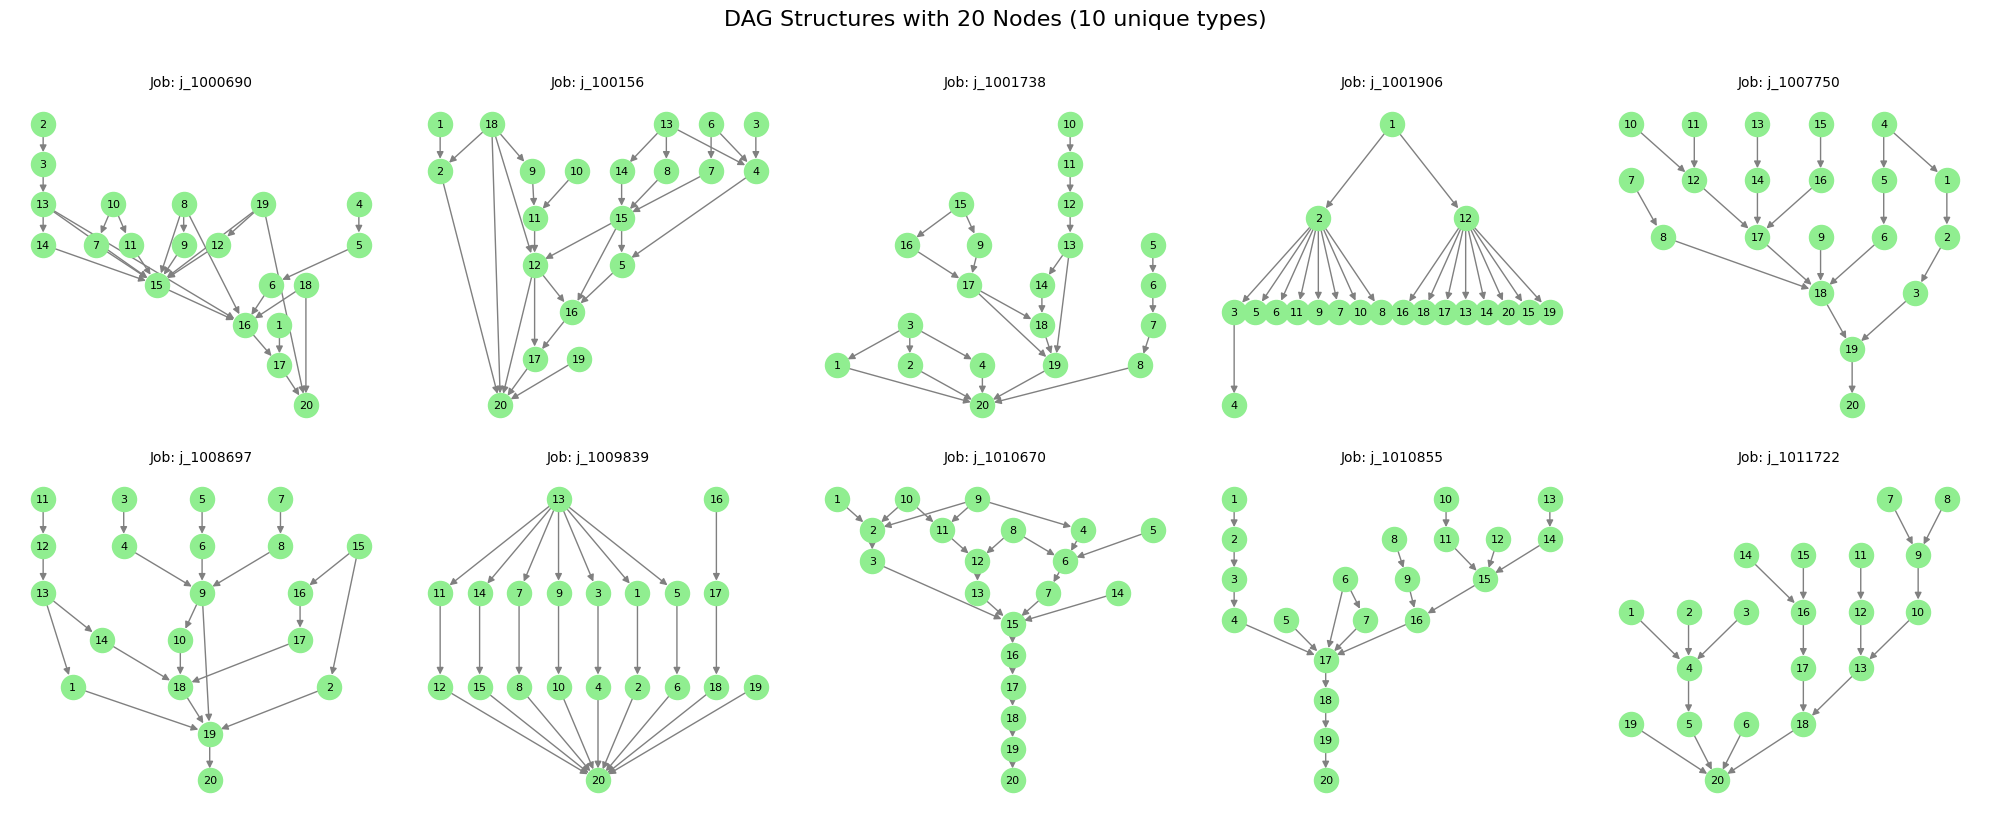

In [2]:
# ...existing code...
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import re
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

# 读取数据 (如果之前已经读取过df，这行可以注释掉)
# df = pd.read_csv("batch_task.csv", header=None, names=["task_name", "instance_num", "job_name", "task_type", "status", "start_time", "end_time", "plan_cpu", "plan_mem"])

# 目标节点数
target_sizes = [5, 10, 15, 20]
# 每个尺寸需要的不同结构数量
max_graphs_per_size = 10

# 用于存储结果： {size: [(job_name, G), ...]}
collected_graphs = {s: [] for s in target_sizes}
# 用于存储图的哈希值，防止重复结构： {size: set(hashes)}
structure_hashes = {s: set() for s in target_sizes}

# 按 job_name 分组
grouped = df.groupby("job_name")

print("正在筛选和构建DAG...")

for job_name, group in grouped:
    # 1. 检查节点数量是否符合要求
    num_nodes = len(group)
    if num_nodes not in target_sizes:
        continue

    # 如果该尺寸已经收集满了，跳过
    if len(collected_graphs[num_nodes]) >= max_graphs_per_size:
        # 检查是否所有尺寸都收集满了
        if all(len(v) >= max_graphs_per_size for v in collected_graphs.values()):
            break
        continue

    # 2. 构建 DAG
    G = nx.DiGraph()
    valid_dag = True

    for _, row in group.iterrows():
        task_name = row["task_name"]
        # 简单的逻辑：如果任务名全是 task_ 开头且没有依赖信息，通常无法构建DAG，跳过
        if task_name.startswith("task_") and "_" not in task_name[5:]:
            valid_dag = False
            break

        numbers = re.findall(r"\d+", task_name)
        if not numbers:
            continue

        task_id = numbers[0]
        dependencies = numbers[1:]

        G.add_node(task_id)
        for dep in dependencies:
            G.add_edge(dep, task_id)

    if not valid_dag or G.number_of_nodes() != num_nodes:
        continue

    # 3. 结构去重 (同构检测)
    # 使用 Weisfeiler-Lehman 哈希算法生成图的结构指纹
    try:
        # node_attr=None 表示只关心拓扑结构，不关心节点标签
        g_hash = weisfeiler_lehman_graph_hash(G)
    except:
        continue  # 某些特殊空图可能报错

    if g_hash not in structure_hashes[num_nodes]:
        structure_hashes[num_nodes].add(g_hash)
        collected_graphs[num_nodes].append((job_name, G))

print("筛选完成。")
for size in target_sizes:
    print(f"节点数 {size}: 找到了 {len(collected_graphs[size])} 种不同结构的图")

# 4. 绘图
for size in target_sizes:
    graphs_list = collected_graphs[size]
    if not graphs_list:
        continue

    count = len(graphs_list)
    # 计算子图布局 (例如 2列 或 5列)
    cols = 5
    rows = (count + cols - 1) // cols

    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle(f"DAG Structures with {size} Nodes ({count} unique types)", fontsize=16, y=1.02)

    for i, (job_name, G) in enumerate(graphs_list):
        ax = plt.subplot(rows, cols, i + 1)

        try:
            # 优先尝试 graphviz 布局，层级结构更清晰
            pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
        except:
            # 如果没有安装 graphviz，回退到 kamada_kawai 或 spring
            pos = nx.kamada_kawai_layout(G)

        nx.draw(G, pos, ax=ax, with_labels=True, node_size=300, node_color="lightgreen", font_size=8, arrowsize=10, edge_color="gray")
        ax.set_title(f"Job: {job_name}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()